# *Livrable Présentation Projet*

Dans un premier temps nous prenons connaisance des differents fichier de données.

Commencons par les csv general_data, employee_survey_data, manager_survey




## Lecture des datas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
import os
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def resolve_project_dir(folder_name):
    candidates = [
        os.path.join(os.getcwd(), folder_name),
        os.path.join(os.getcwd(), '..', folder_name)
    ]
    for candidate in candidates:
        if os.path.isdir(candidate):
            return candidate
    return candidates[0]

def basename_cross_platform(path_value):
    return str(path_value).replace('\\\\', '/').split('/')[-1]

SOURCE_DIR = resolve_project_dir('Source')
FIG_DIR = resolve_project_dir('fig')
CONSOLIDATED_DIR = resolve_project_dir('consolidated_data')

## La fonction ci-dessous permet d'analyser chaque colonnes du fichier CSV choisis. 

In [2]:
def explore_data(csv_file):
    csv_basename = basename_cross_platform(csv_file)
    name = os.path.splitext(csv_basename)[0]   # enleve .csv
    general = name.split('_')[0]
    csv_path = csv_file if os.path.exists(csv_file) else os.path.join(SOURCE_DIR, csv_basename)
    df = pd.read_csv(csv_path)
    print(df.info())
    print(df.describe())
    print(df.head())
    # Visualize missing data
    msno.matrix(df)
    fig_subdir = os.path.join(FIG_DIR, general)
    os.makedirs(fig_subdir, exist_ok=True)
    plt.savefig(os.path.join(fig_subdir, 'missing_data_matrix.png'))
    plt.show()

    # Visualize distributions of numerical features
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    if numerical_columns.empty:
        print('No numerical columns found.')
    else:
        for column in numerical_columns:
            plt.figure(figsize=(10, 4))
            sns.countplot(x=df[column])
            plt.title(f'Distribution of {column}')
            plt.xticks(rotation=45)
            plt.savefig(os.path.join(fig_subdir, f'distribution_{column}.png'))

    # For categorical columns, use mode imputation
    categorical_columns = df.select_dtypes(include=['object']).columns
    if categorical_columns.empty:
        print('No categorical columns found.')
    else:
        # Univariate analysis for categorical features
        for column in categorical_columns:
            plt.figure(figsize=(10, 4))
            sns.countplot(x=df[column])
            plt.title(f'Distribution of {column}')
            plt.xticks(rotation=45)
            plt.savefig(os.path.join(fig_subdir, f'distribution_{column}.png'))


## Test de la fonction sur general data

On observe que notre dataframe contient 4410 lignes ainsi que 24 colonnes, on observe également que 
NumCompaniesWorked et TotalWorkingYears ont des lignes manquantes il va donc falloir leur rajouter des valeurs en prenant en compte la median

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

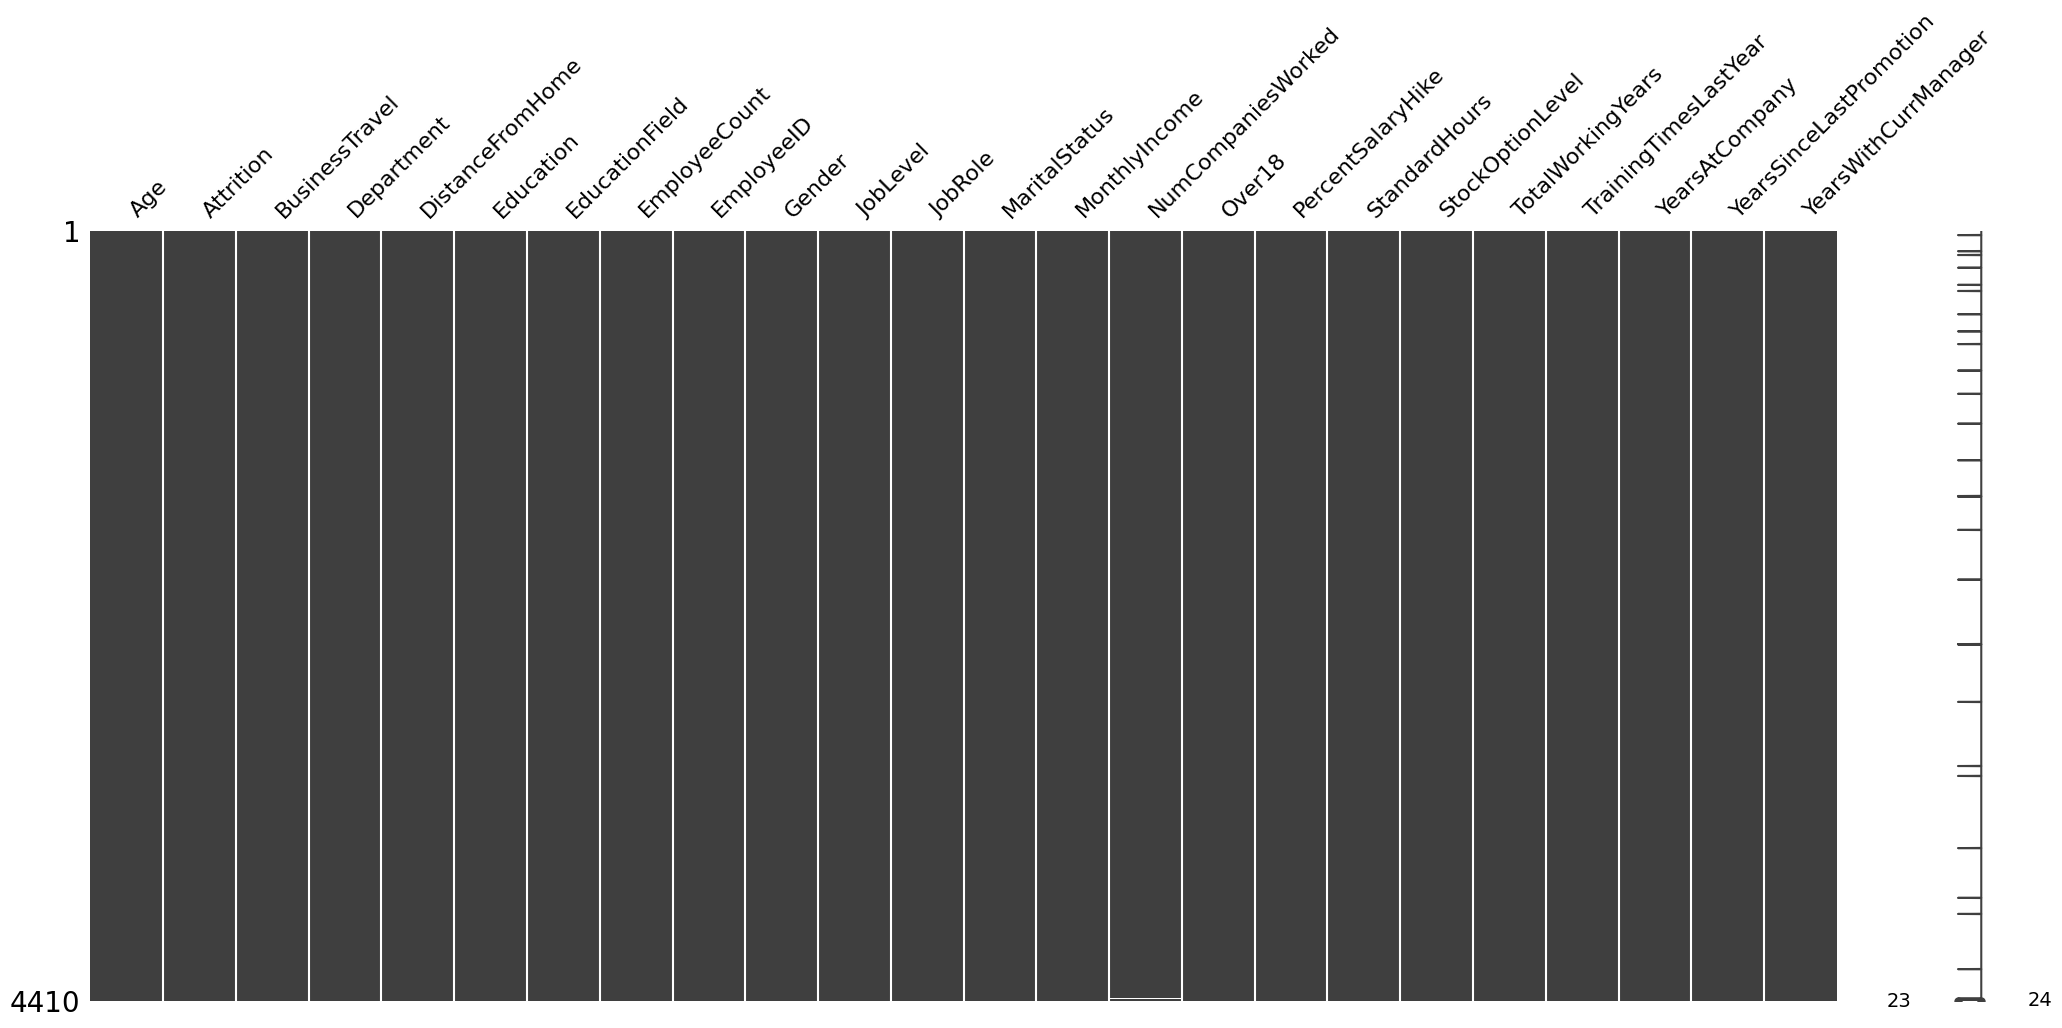

C:\Users\Natha\AppData\Local\Temp\ipykernel_47836\3450547478.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


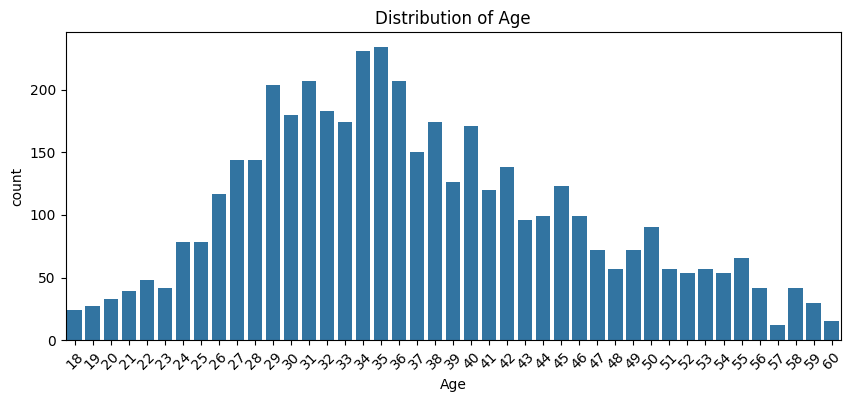

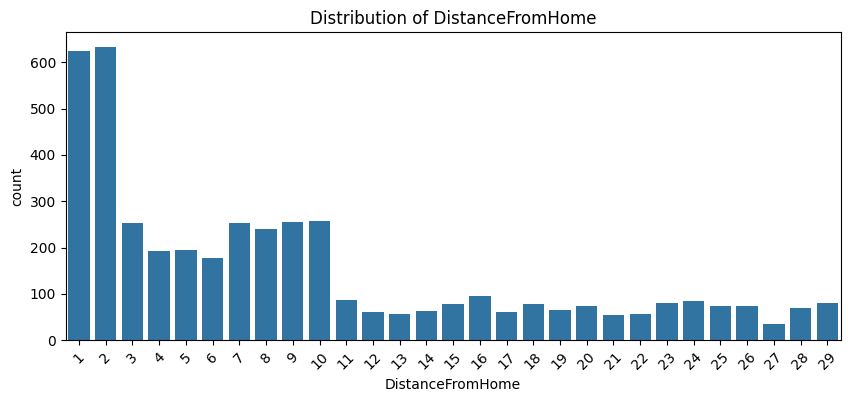

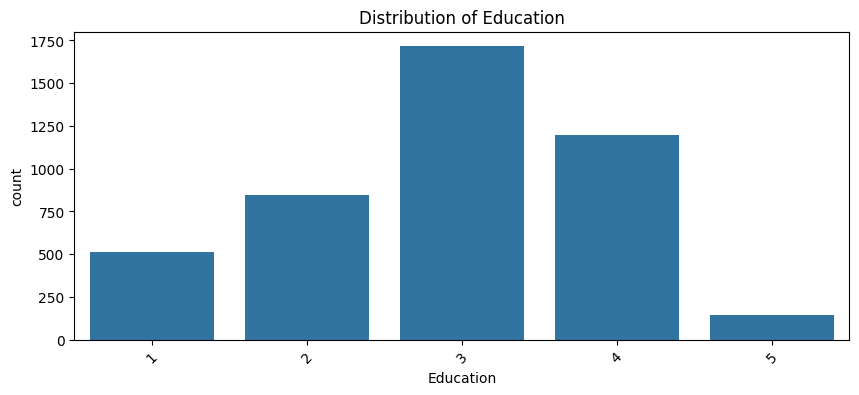

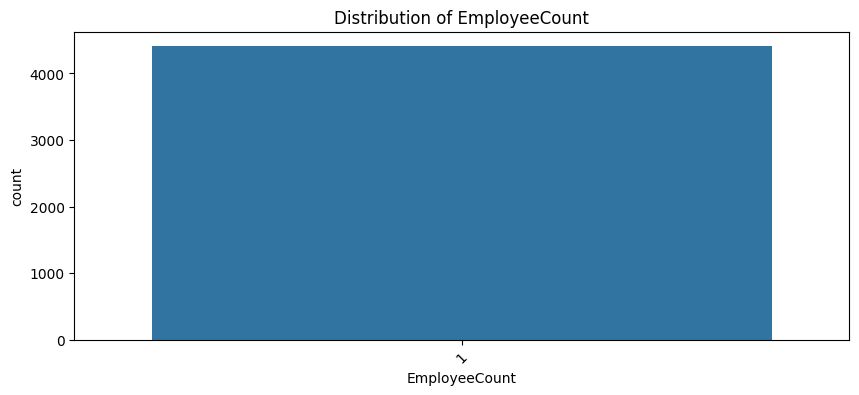

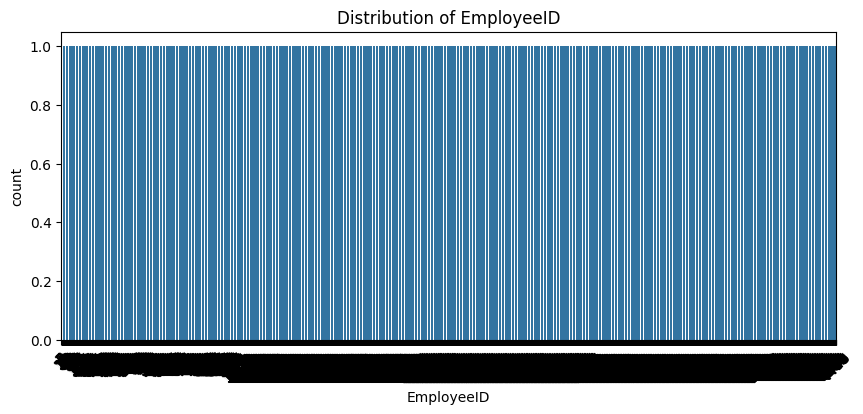

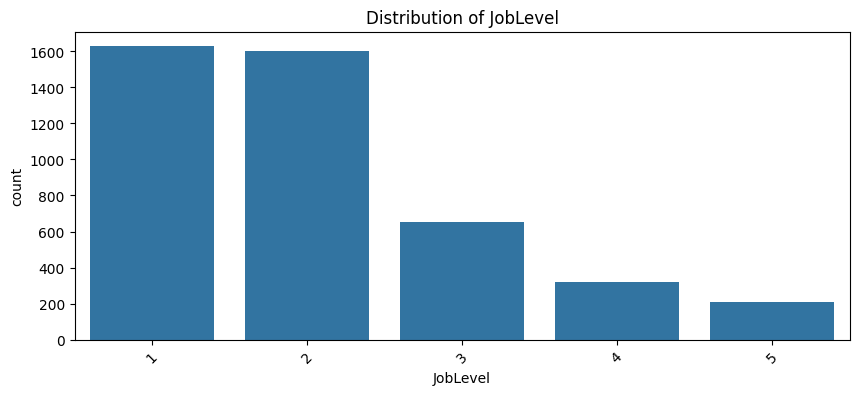

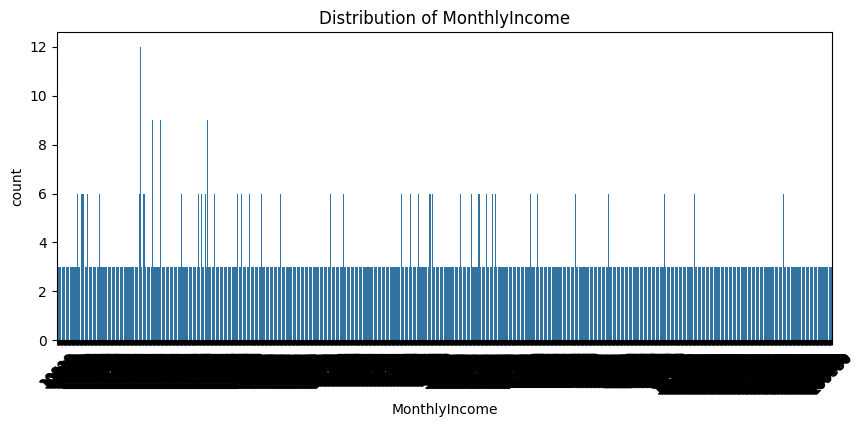

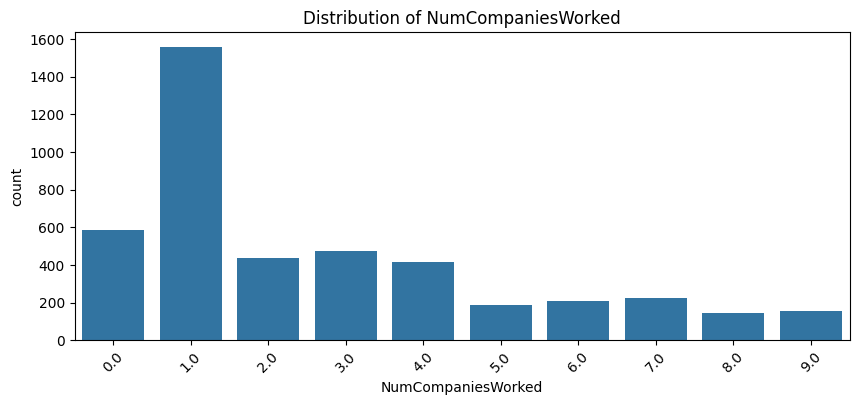

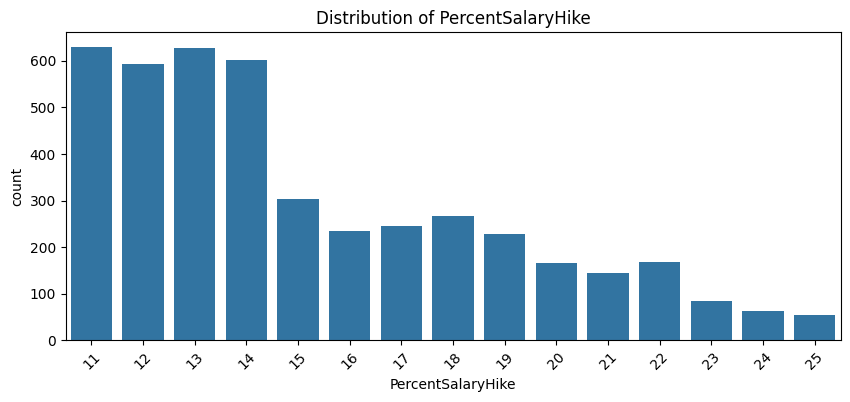

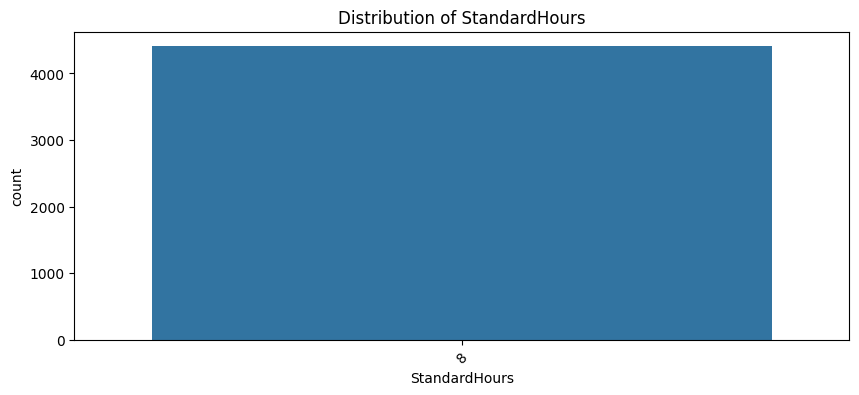

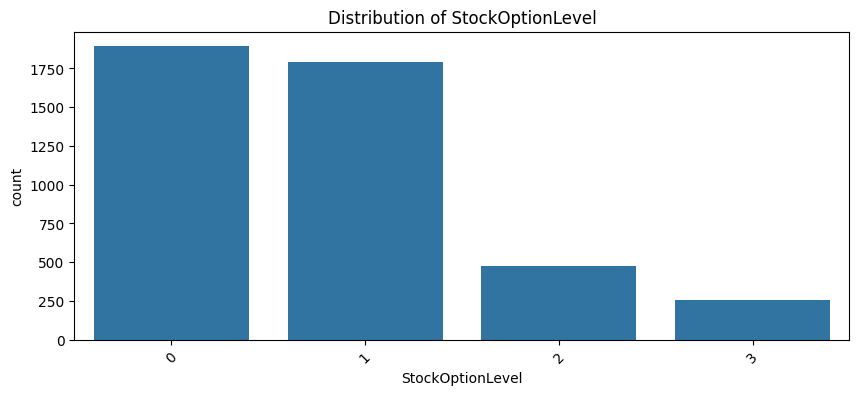

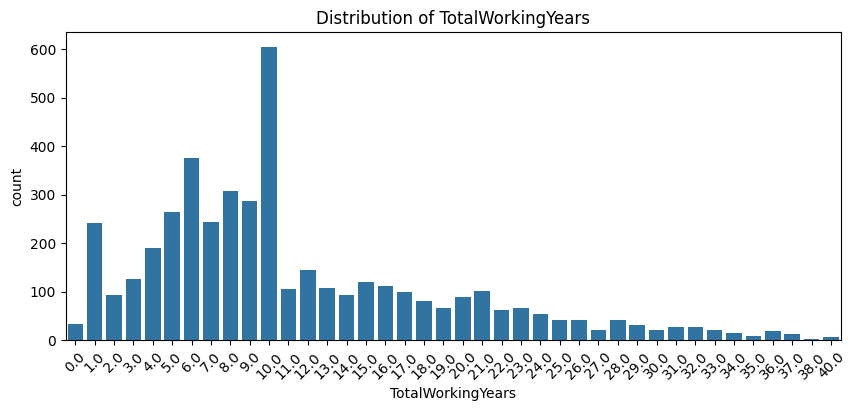

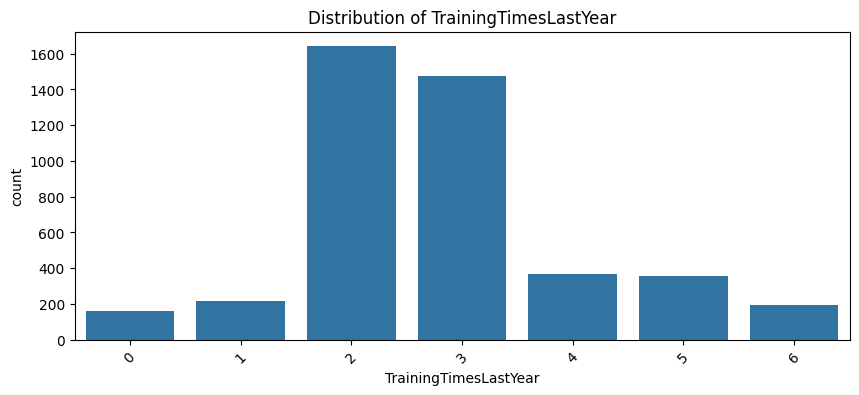

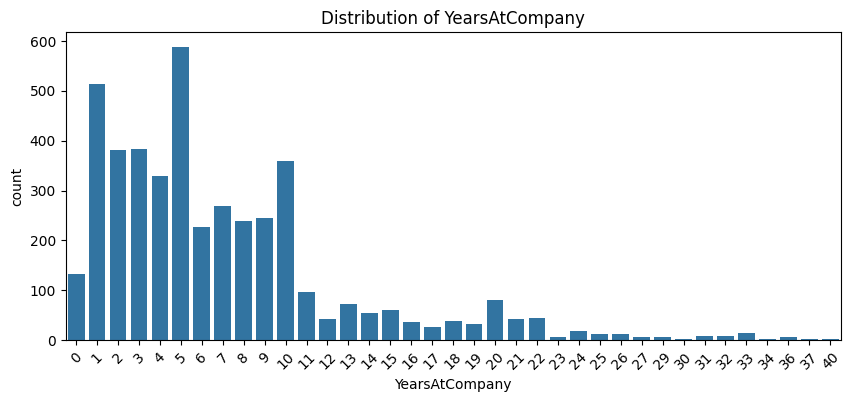

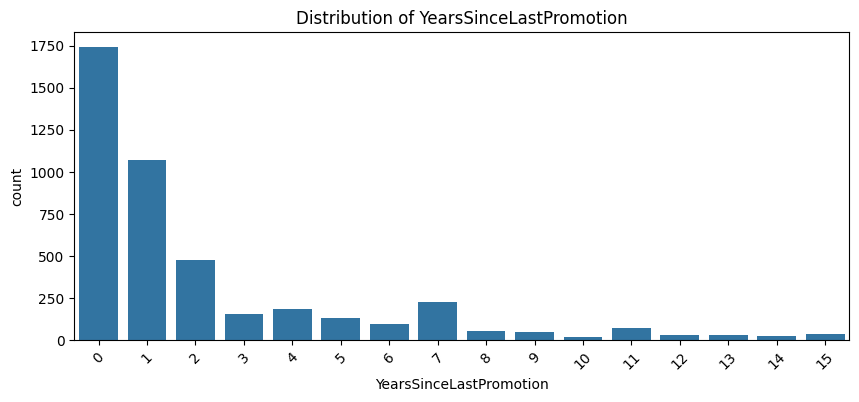

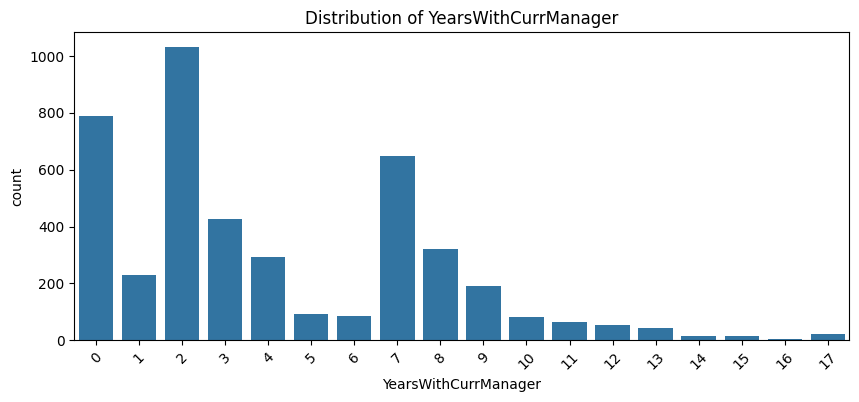

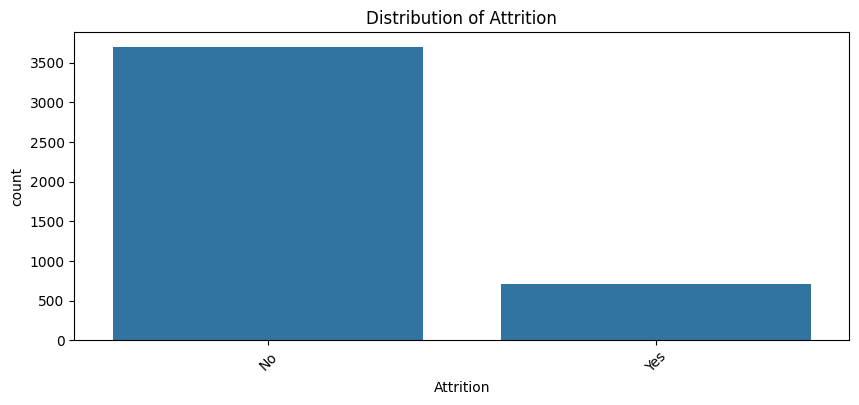

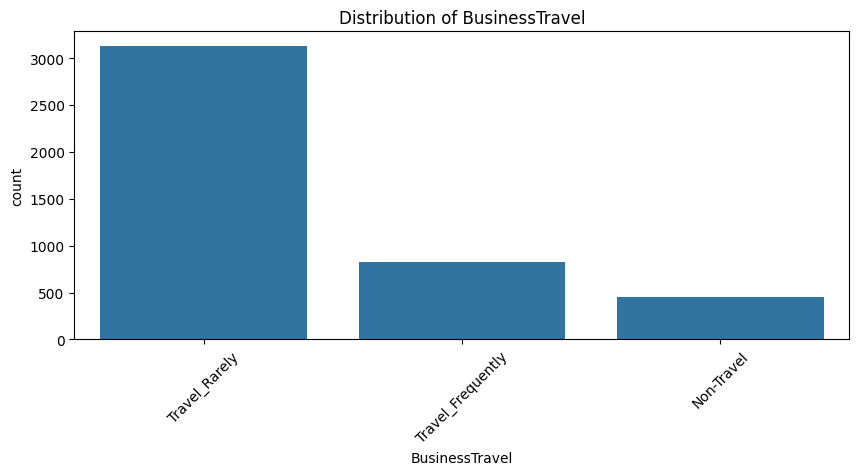

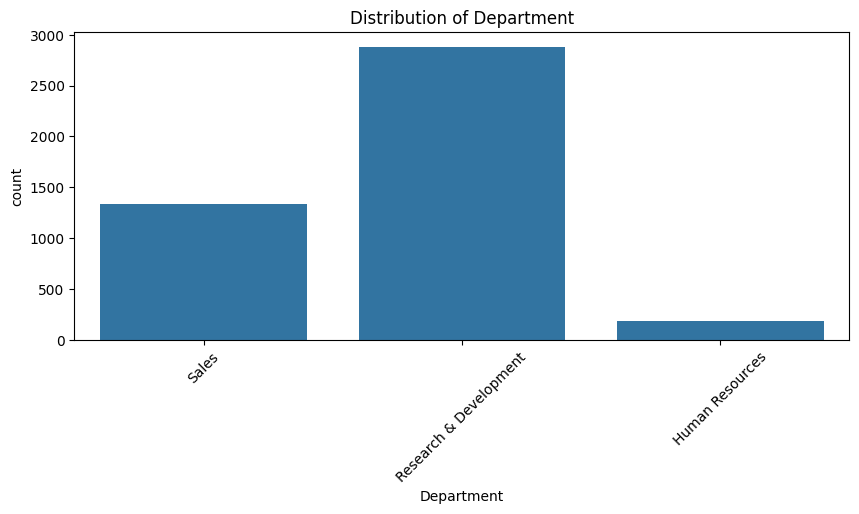

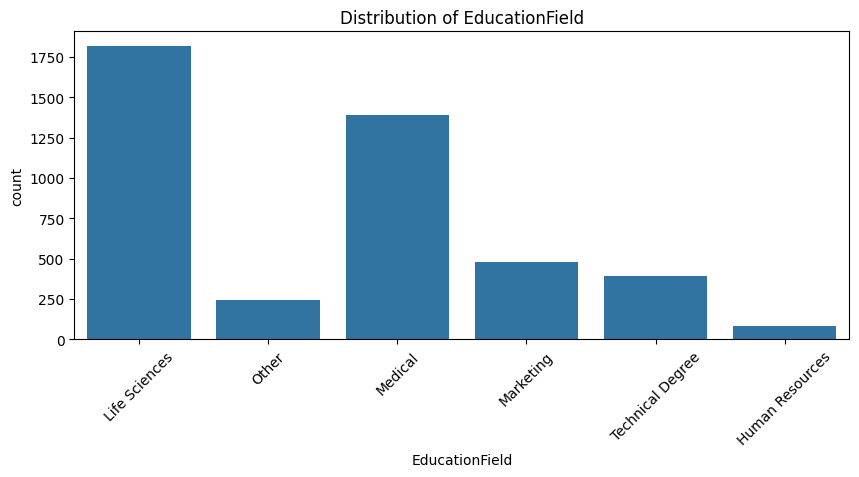

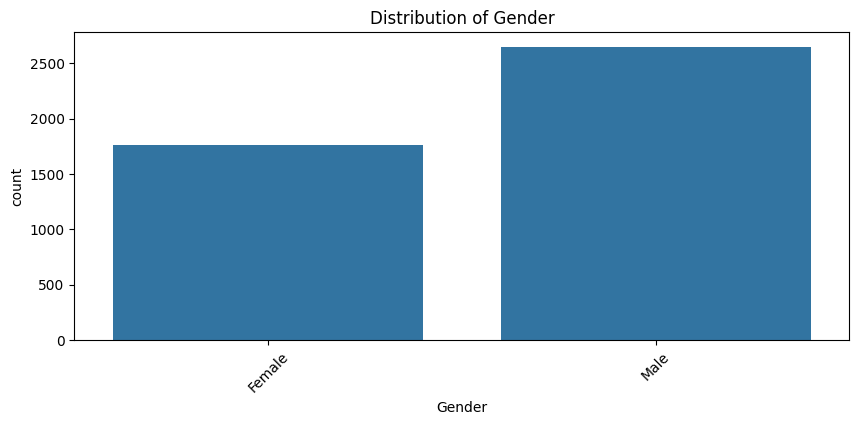

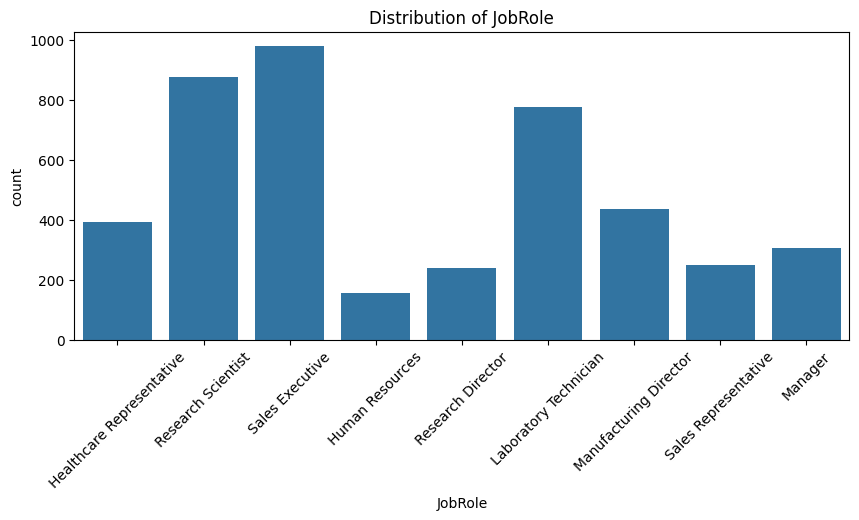

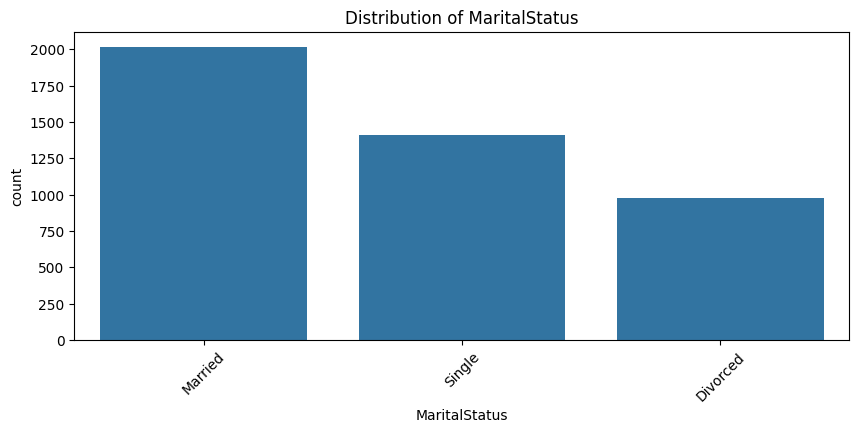

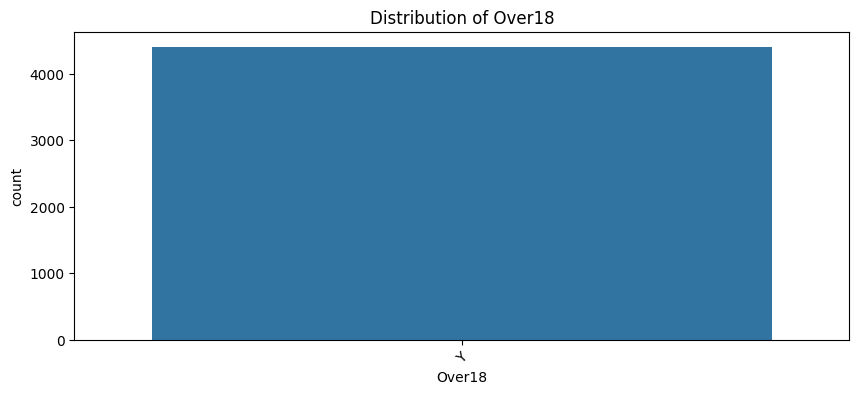

In [3]:
explore_data("general_data.csv")

On observe que certaine valeur sont constantes il faudra donc les supprimers pour l'entrainement du model car ne sont pas utiles 

# La meme chose maintenant pour employee survey :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB
None
        EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
count  4410.000000              4385.000000      4390.000000      4372.000000
mean   2205.500000                 2.723603         2.728246         2.761436
std    1273.201673                 1.092756         1.101253         0.706245
min       1.000000                 1.000000         1.000000         1.000000
25%    1103.250000                 2.000000         2.000000         2.000000
50%    2205.500000                 3.000000  

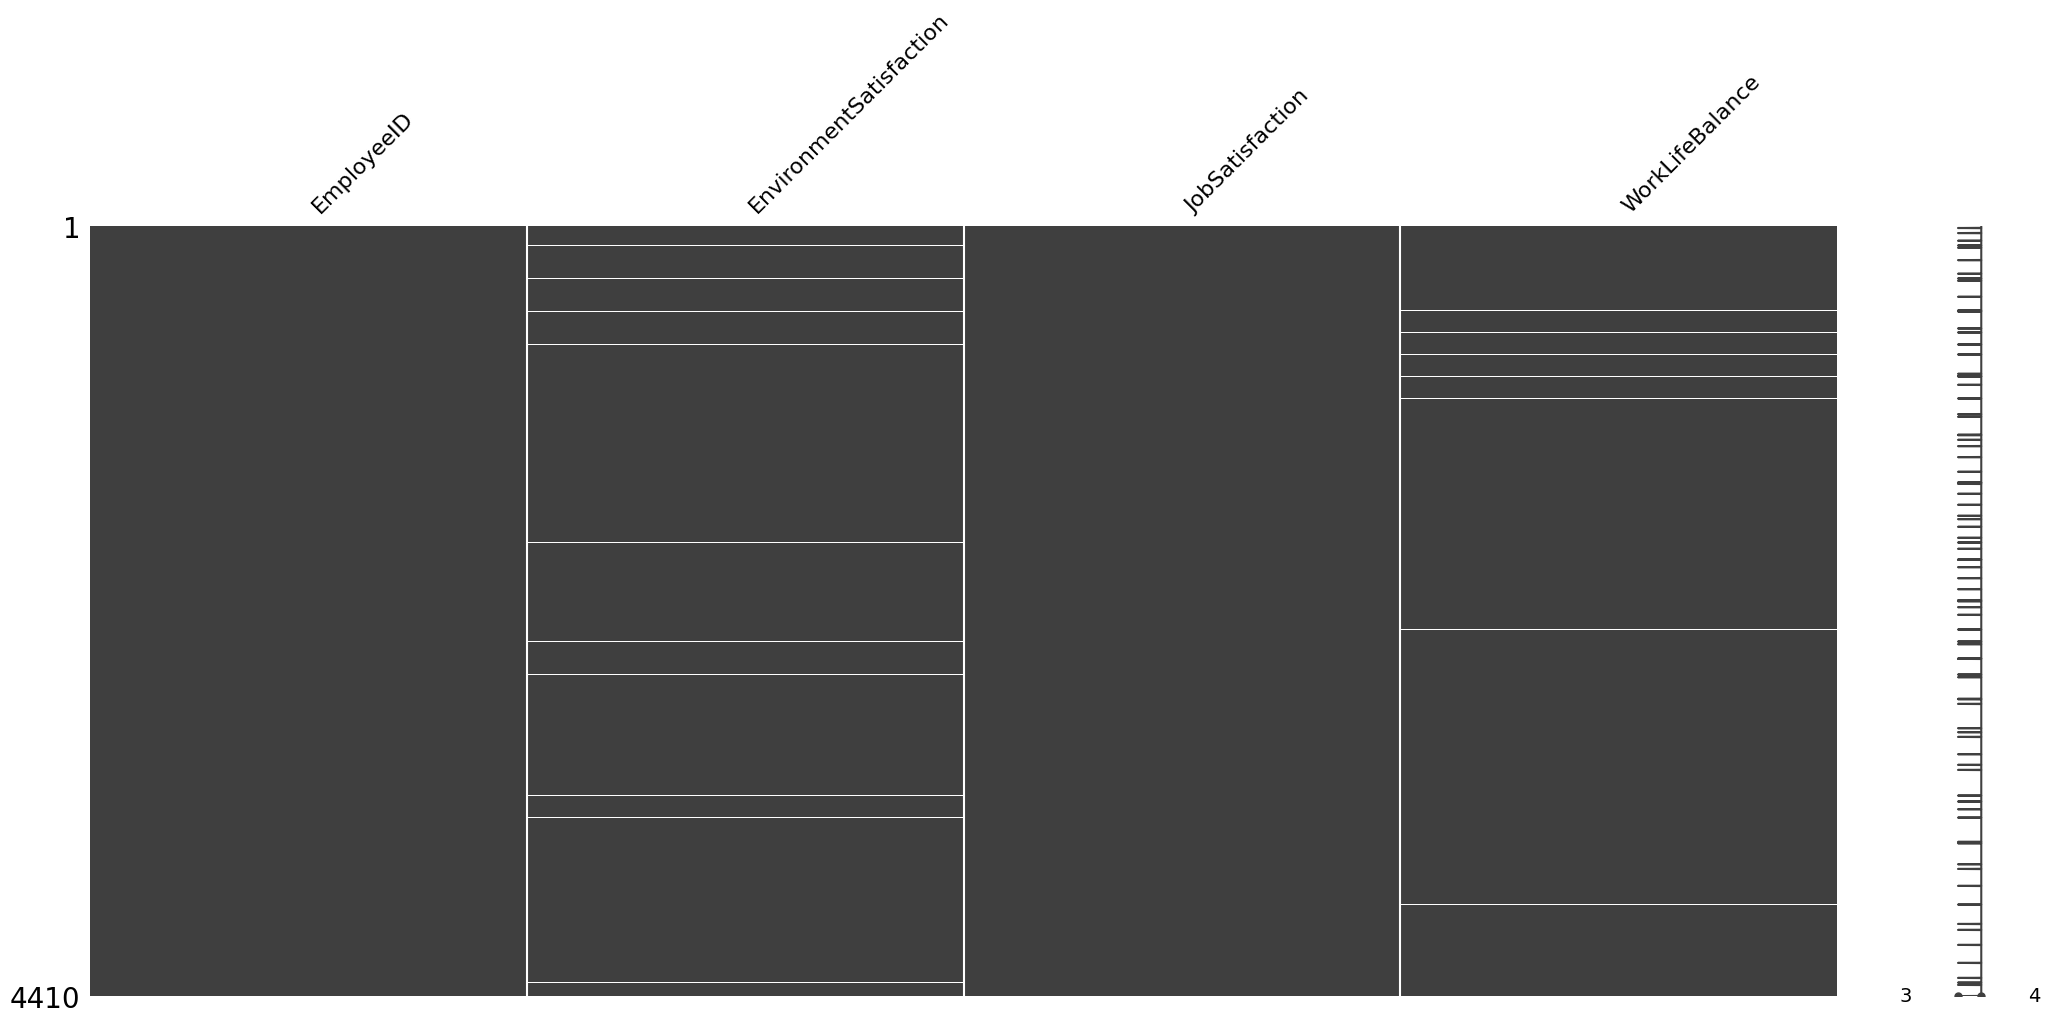

No categorical columns found.


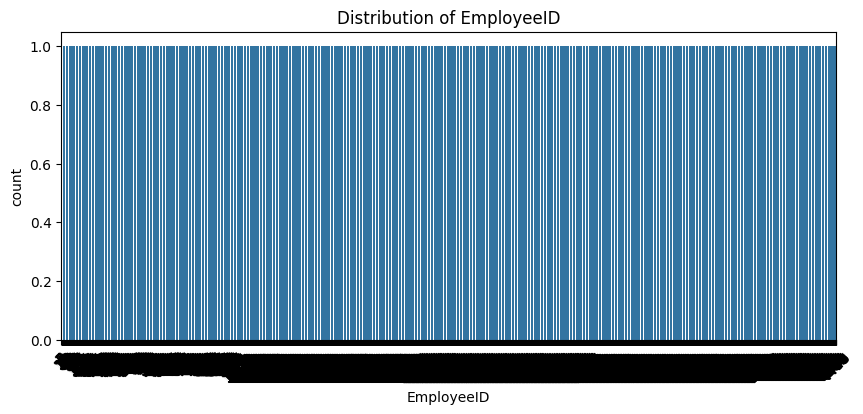

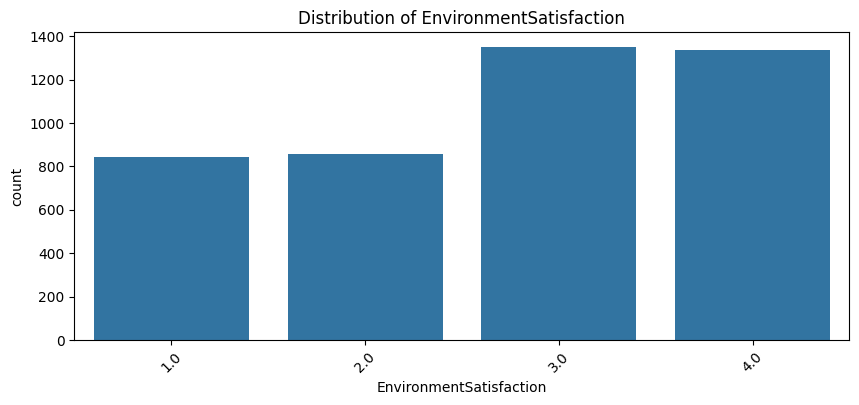

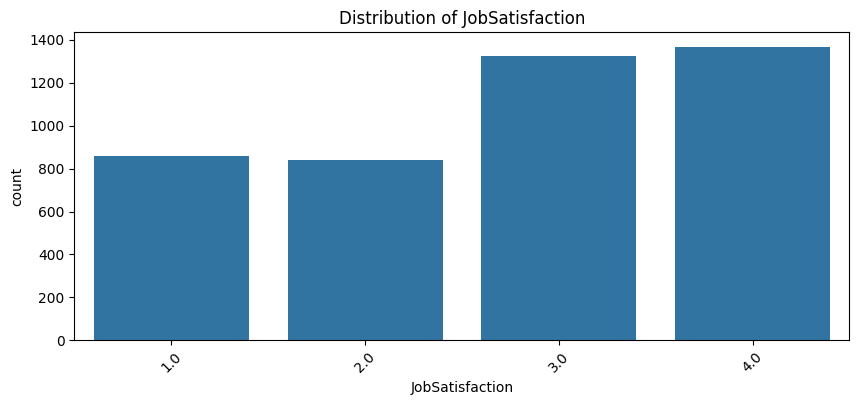

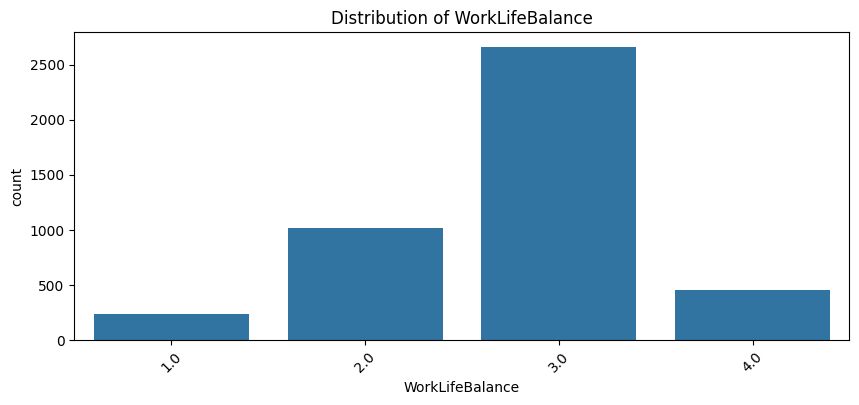

In [4]:
explore_data("employee_survey_data.csv")

# Et enfin pour manager survey:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB
None
        EmployeeID  JobInvolvement  PerformanceRating
count  4410.000000     4410.000000        4410.000000
mean   2205.500000        2.729932           3.153741
std    1273.201673        0.711400           0.360742
min       1.000000        1.000000           3.000000
25%    1103.250000        2.000000           3.000000
50%    2205.500000        3.000000           3.000000
75%    3307.750000        3.000000           3.000000
max    4410.000000        4.000000           4.000000
   EmployeeID  JobInvolvement  PerformanceRating
0           1               3                  3
1           2               2      

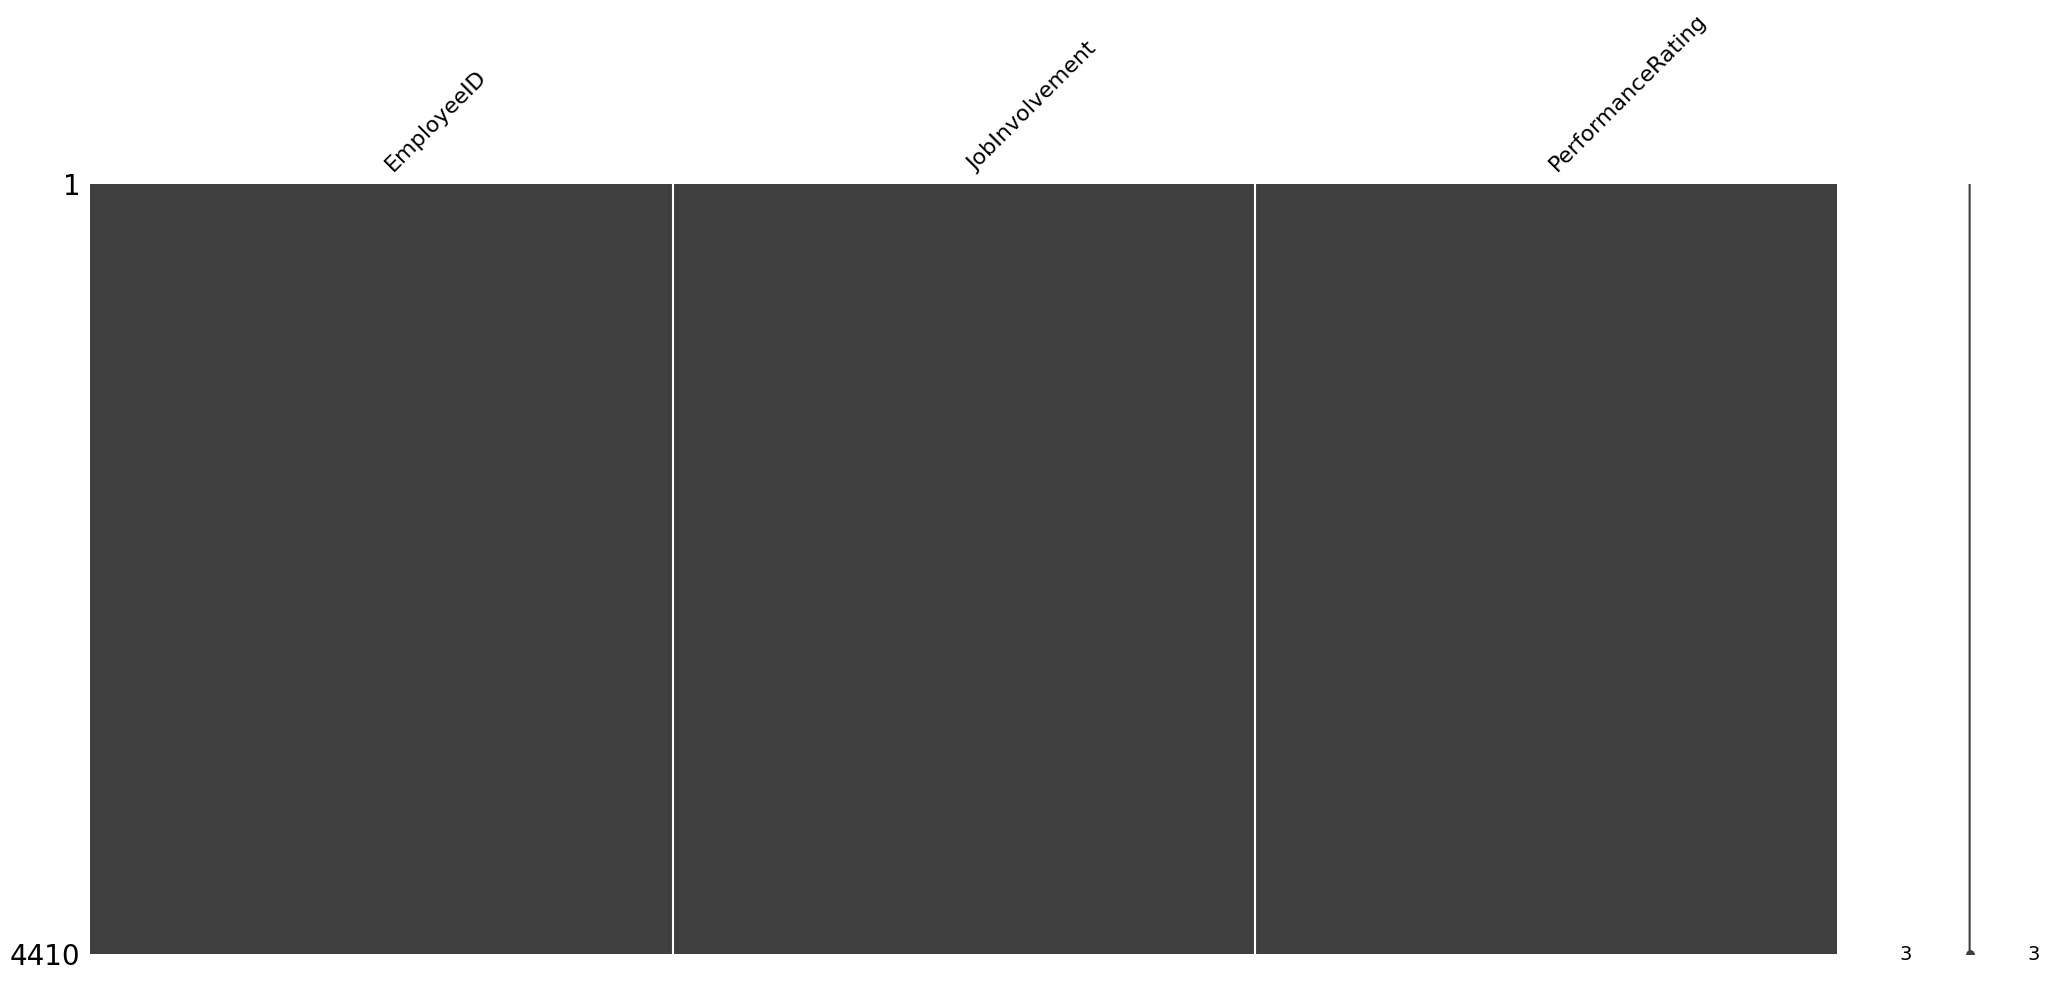

No categorical columns found.


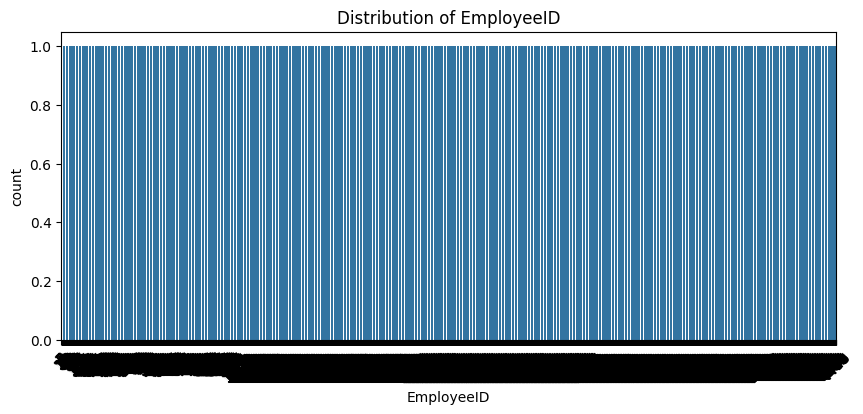

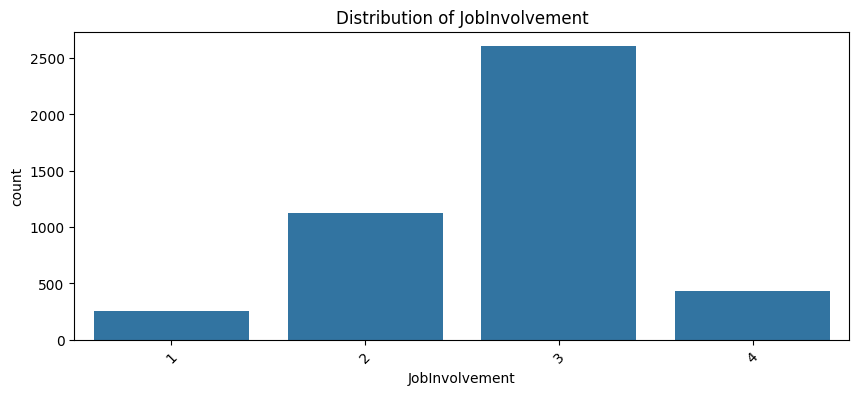

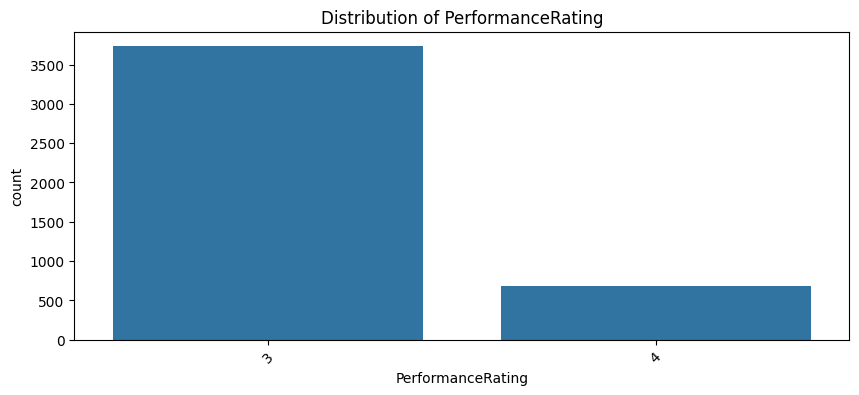

In [5]:
explore_data("manager_survey_data.csv")

# Maintenant nous allons remplacer les valeurs manquantes par les medians puis enregistrer les nouveaux dataframe pour les réutiliser ulterierement 

## Fonction gestion des valeurs manquantes:

In [6]:

def dataframe_consolidation(df_to_consolidate,new_csv):
    input_basename = basename_cross_platform(df_to_consolidate)
    source_path = df_to_consolidate if os.path.exists(df_to_consolidate) else os.path.join(SOURCE_DIR, input_basename)
    df = pd.read_csv(source_path)
    print(df.info())
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    if numerical_columns.empty:
        print('No numerical columns found.')
    else:
        df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())
        print(numerical_columns)
    # For categorical columns, use mode imputation
    categorical_columns = df.select_dtypes(include=['object']).columns
    if categorical_columns.empty:
        print('No categorical columns found.')
    else:
        df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])
        print(categorical_columns)
    # Verify that there are no more missing values
    print(df.isnull().sum())
    os.makedirs(CONSOLIDATED_DIR, exist_ok=True)
    df.to_csv(os.path.join(CONSOLIDATED_DIR, new_csv), index=False)
    return df

In [7]:
dataframe_consolidation('general_data.csv','general_data_consolidated.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,No,Travel_Rarely,Research & Development,5,4,Medical,1,4406,Female,...,3.0,Y,17,8,1,10.0,5,3,0,2
4406,29,No,Travel_Rarely,Research & Development,2,4,Medical,1,4407,Male,...,2.0,Y,15,8,0,10.0,2,3,0,2
4407,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,1,4408,Male,...,0.0,Y,20,8,0,5.0,4,4,1,2
4408,42,No,Travel_Rarely,Sales,18,2,Medical,1,4409,Male,...,0.0,Y,14,8,1,10.0,2,9,7,8


In [8]:
dataframe_consolidation('employee_survey_data.csv','employee_survey_data_consolidated.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB
None
Index(['EmployeeID', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance'],
      dtype='object')
No categorical columns found.
EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
dtype: int64


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0
...,...,...,...,...
4405,4406,4.0,1.0,3.0
4406,4407,4.0,4.0,3.0
4407,4408,1.0,3.0,3.0
4408,4409,4.0,1.0,3.0


In [9]:
dataframe_consolidation('manager_survey_data.csv','manager_survey_data_consolidated.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB
None
Index(['EmployeeID', 'JobInvolvement', 'PerformanceRating'], dtype='object')
No categorical columns found.
EmployeeID           0
JobInvolvement       0
PerformanceRating    0
dtype: int64


,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3
...,...,...,...
4405,4406,3,3
4406,4407,2,3
4407,4408,3,4
4408,4409,2,3


## Maintenant nous allons merge les 3 dataframe pour en faire qu'un.

In [10]:
import pandas as pd
import os
from pathlib import Path


def merge_survey_data(
    general_data_path: str,
    employee_survey_path: str,
    manager_survey_path: str,
    output_path: str = None,
    employee_id_column: str = "EmployeeID",
    columns_to_add: list = None
):
    """
    Fusionne les donnÃ©es d'enquÃªte avec les donnÃ©es gÃ©nÃ©rales.
    
    Parameters:
    -----------
    general_data_path : str
        Chemin vers le fichier CSV/Excel contenant les donnÃ©es gÃ©nÃ©rales
    employee_survey_path : str
        Chemin vers le fichier CSV/Excel contenant les donnÃ©es d'enquÃªte employÃ©
    manager_survey_path : str
        Chemin vers le fichier CSV/Excel contenant les donnÃ©es d'enquÃªte manager
    output_path : str, optional
        Chemin de sortie pour le fichier fusionnÃ©. Si None, remplace le fichier gÃ©nÃ©ral
    employee_id_column : str, default="EmployeeID"
        Nom de la colonne utilisÃ©e pour la jointure
    columns_to_add : list, optional
        Liste des colonnes Ã  ajouter. Si None, utilise les colonnes par dÃ©faut
        
    Returns:
    --------
    pd.DataFrame
        DataFrame contenant les donnÃ©es fusionnÃ©es
    """
    
    # Colonnes par dÃ©faut Ã  ajouter
    if columns_to_add is None:
        columns_to_add = [
            "EnvironmentSatisfaction",
            "JobSatisfaction", 
            "WorkLifeBalance",
            "JobInvolvement",
            "PerformanceRating"
        ]
    
    # DÃ©terminer le chemin de sortie
    if output_path is None:
        # Par dÃ©faut, ne jamais Ã©craser les fichiers Source
        output_path = str(Path(general_data_path).parent.parent / "Output" / "general_data_merged.csv")

    # Refuser toute sortie dans le dossier Source
    output_path_obj = Path(output_path).resolve()
    source_dir_obj = Path(general_data_path).resolve().parent
    if source_dir_obj in output_path_obj.parents or output_path_obj == Path(general_data_path).resolve():
        raise ValueError("Le fichier de sortie ne doit pas Ãªtre dans le dossier Source.")

    # CrÃ©er le dossier parent si nÃ©cessaire
    output_path_obj = Path(output_path)
    output_path_obj.parent.mkdir(parents=True, exist_ok=True)
    
    print(f"Lecture du fichier gÃ©nÃ©ral: {general_data_path}")
    # Lire le fichier gÃ©nÃ©ral (support CSV et Excel)
    if general_data_path.endswith('.xlsx') or general_data_path.endswith('.xls'):
        general_df = pd.read_excel(general_data_path)
    else:
        general_df = pd.read_csv(general_data_path)
    
    print(f"Lecture du fichier d'enquÃªte employÃ©: {employee_survey_path}")
    # Lire le fichier d'enquÃªte employÃ©
    if employee_survey_path.endswith('.xlsx') or employee_survey_path.endswith('.xls'):
        employee_survey_df = pd.read_excel(employee_survey_path)
    else:
        employee_survey_df = pd.read_csv(employee_survey_path)
    
    print(f"Lecture du fichier d'enquÃªte manager: {manager_survey_path}")
    # Lire le fichier d'enquÃªte manager
    if manager_survey_path.endswith('.xlsx') or manager_survey_path.endswith('.xls'):
        manager_survey_df = pd.read_excel(manager_survey_path)
    else:
        manager_survey_df = pd.read_csv(manager_survey_path)
    
    # VÃ©rifier que la colonne EmployeeID existe dans tous les fichiers
    for df_name, df in [("gÃ©nÃ©ral", general_df), 
                         ("enquÃªte employÃ©", employee_survey_df),
                         ("enquÃªte manager", manager_survey_df)]:
        if employee_id_column not in df.columns:
            raise ValueError(
                f"La colonne '{employee_id_column}' n'existe pas dans le fichier {df_name}"
            )
    
    # Supprimer les colonnes existantes si elles existent dÃ©jÃ  (pour Ã©viter les doublons)
    columns_to_remove = [col for col in columns_to_add if col in general_df.columns]
    if columns_to_remove:
        print(f"Suppression des colonnes existantes: {columns_to_remove}")
        general_df = general_df.drop(columns=columns_to_remove)
    
    # Supprimer aussi les colonnes avec suffixes _x et _y si elles existent
    suffix_columns_to_remove = []
    for col in columns_to_add:
        if f"{col}_x" in general_df.columns:
            suffix_columns_to_remove.append(f"{col}_x")
        if f"{col}_y" in general_df.columns:
            suffix_columns_to_remove.append(f"{col}_y")
    if suffix_columns_to_remove:
        print(f"Suppression des colonnes avec suffixes: {suffix_columns_to_remove}")
        general_df = general_df.drop(columns=suffix_columns_to_remove)
    
    # SÃ©lectionner uniquement les colonnes Ã  ajouter qui existent dans les fichiers d'enquÃªte
    employee_columns = [col for col in columns_to_add if col in employee_survey_df.columns]
    manager_columns = [col for col in columns_to_add if col in manager_survey_df.columns]
    
    # CrÃ©er les DataFrames avec seulement EmployeeID et les colonnes Ã  fusionner
    employee_to_merge = employee_survey_df[[employee_id_column] + employee_columns]
    manager_to_merge = manager_survey_df[[employee_id_column] + manager_columns]
    
    print(f"Fusion des colonnes d'enquÃªte employÃ©: {employee_columns}")
    # Fusionner avec les donnÃ©es d'enquÃªte employÃ© (sans suffixes car les colonnes n'existent pas)
    merged_df = general_df.merge(
        employee_to_merge,
        on=employee_id_column,
        how='left',
        suffixes=('', '_temp')
    )
    # Supprimer les colonnes temporaires avec suffixe si elles existent
    temp_cols = [col for col in merged_df.columns if col.endswith('_temp')]
    if temp_cols:
        merged_df = merged_df.drop(columns=temp_cols)
    
    print(f"Fusion des colonnes d'enquÃªte manager: {manager_columns}")
    # Fusionner avec les donnÃ©es d'enquÃªte manager (sans suffixes car les colonnes n'existent pas)
    merged_df = merged_df.merge(
        manager_to_merge,
        on=employee_id_column,
        how='left',
        suffixes=('', '_temp')
    )
    # Supprimer les colonnes temporaires avec suffixe si elles existent
    temp_cols = [col for col in merged_df.columns if col.endswith('_temp')]
    if temp_cols:
        merged_df = merged_df.drop(columns=temp_cols)
    
    # VÃ©rifier les colonnes manquantes
    missing_columns = [col for col in columns_to_add if col not in merged_df.columns]
    if missing_columns:
        print(f"Attention: Les colonnes suivantes n'ont pas Ã©tÃ© trouvÃ©es: {missing_columns}")
    
    print(f"Sauvegarde du fichier fusionnÃ©: {output_path}")
    # Sauvegarder le rÃ©sultat
    if output_path.endswith('.xlsx') or output_path.endswith('.xls'):
        merged_df.to_excel(output_path, index=False)
    else:
        merged_df.to_csv(output_path, index=False)
    
    print("Fusion terminee avec succes!")
    print(f"  - Nombre de lignes: {len(merged_df)}")
    print(f"  - Nombre de colonnes: {len(merged_df.columns)}")
    print(f"  - Colonnes ajoutees: {[col for col in columns_to_add if col in merged_df.columns]}")
    
    return merged_df


"""
Fonction principale avec les chemins par dÃ©faut pour ce projet.
"""
# DÃ©finir les chemins des fichiers
script_dir = Path.cwd()   # dossier courant du notebook
project_candidates = [script_dir, script_dir.parent]
project_dir = next((p for p in project_candidates if (p / 'consolidated_data').exists() or (p / 'Source').exists()), script_dir.parent)
source_dir = project_dir / 'consolidated_data'
output_dir = project_dir / 'Output'

# CrÃ©er le dossier Output s'il n'existe pas
output_dir.mkdir(parents=True, exist_ok=True)

general_data_path = source_dir / "general_data_consolidated.csv"
employee_survey_path = source_dir / "employee_survey_data_consolidated.csv"
manager_survey_path = source_dir / "manager_survey_data_consolidated.csv"

# Chemin de sortie dans le dossier Output
output_path = output_dir / "general_data_merged.csv"

# VÃ©rifier que les fichiers existent
for file_path in [general_data_path, employee_survey_path, manager_survey_path]:
    if not file_path.exists():
        raise FileNotFoundError(f"Le fichier {file_path} n'existe pas")

# ExÃ©cuter la fusion
merged_df = merge_survey_data(
    general_data_path=str(general_data_path),
    employee_survey_path=str(employee_survey_path),
    manager_survey_path=str(manager_survey_path),
    output_path=str(output_path)  # Sauvegarde dans le dossier Output
)


Lecture du fichier gÃ©nÃ©ral: c:\Users\Natha\Documents\A5\IA\github_ia\cesi-IA\consolidated_data\general_data_consolidated.csv
Lecture du fichier d'enquÃªte employÃ©: c:\Users\Natha\Documents\A5\IA\github_ia\cesi-IA\consolidated_data\employee_survey_data_consolidated.csv
Lecture du fichier d'enquÃªte manager: c:\Users\Natha\Documents\A5\IA\github_ia\cesi-IA\consolidated_data\manager_survey_data_consolidated.csv
Fusion des colonnes d'enquÃªte employÃ©: ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']
Fusion des colonnes d'enquÃªte manager: ['JobInvolvement', 'PerformanceRating']
Sauvegarde du fichier fusionnÃ©: c:\Users\Natha\Documents\A5\IA\github_ia\cesi-IA\Output\general_data_merged.csv
Fusion terminee avec succes!
  - Nombre de lignes: 4410
  - Nombre de colonnes: 29
  - Colonnes ajoutees: ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


# Il nous reste maintenant les fichiers in out des horraires des employées 

## Analyse sur le fichier in_time.csv

In [11]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os 

extract_path = "../Source/in_time.csv"
data_in_time = pd.read_csv(extract_path)

# Renommer la colonne sans nom par EmployeeID
data_in_time = data_in_time.rename(columns={data_in_time.columns[0]: 'EmployeeID'})

data_in_time.head()

,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09


## Analyse des lignes avec des NaN


ANALYSE DES DATES DANS LES NOMS DE COLONNES

1. EXTRACTION DES DATES:
   Dimensions: (4410, 262)
   Colonnes (premières): ['EmployeeID', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06']
   ✓ 261 dates détectées et analysées

2. TOP 20 DATES AVEC LE PLUS DE NaN:
--------------------------------------------------------------------------------
   ⚪ 2015-01-01 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-14 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-11 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-10 (Tue) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-09 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-05-01 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-12-25 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-26 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-03-05 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-10-02 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-07-17 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-09-17 (Thu) | NaN: 4410/4410 | Rat

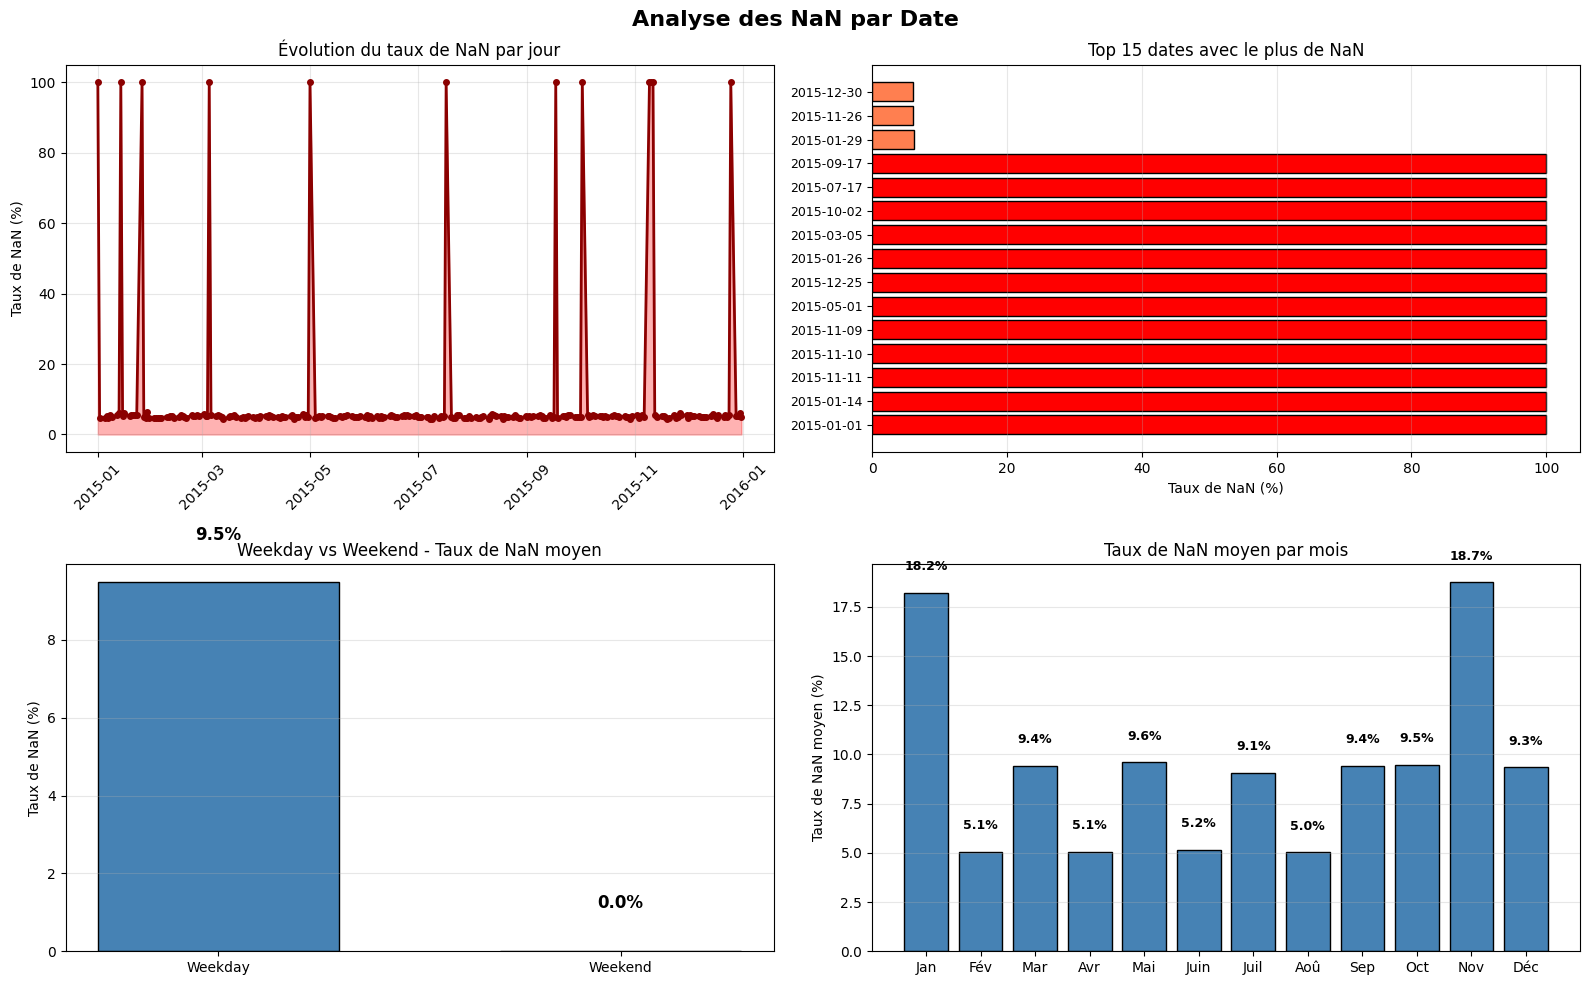


✓ Analyse complétée!


In [12]:
print("\n" + "=" * 80)
print("ANALYSE DES DATES DANS LES NOMS DE COLONNES")
print("=" * 80)

# 1. EXTRAIRE LES DATES DES NOMS DE COLONNES
print("\n1. EXTRACTION DES DATES:")
print(f"   Dimensions: {data_in_time.shape}")
print(f"   Colonnes (premières): {list(data_in_time.columns[:5])}")

# Récupérer toutes les colonnes sauf la première (EmployeeID)
date_columns = data_in_time.columns[1:]

# Convertir les noms de colonnes en dates
dates = []
for col in date_columns:
    try:
        date = pd.to_datetime(col, errors='coerce')
        dates.append(date)
    except:
        dates.append(None)

# Créer un dataframe avec les stats
daily_stats = []

for col, date in zip(date_columns, dates):
    if date is not None and pd.notna(date):
        nan_count = data_in_time[col].isnull().sum()
        total_values = len(data_in_time)
        nan_rate = (nan_count / total_values * 100) if total_values > 0 else 0
        day_name = date.day_name()
        is_weekend = date.dayofweek >= 5
        month = date.month
        
        daily_stats.append({
            'Date': date,
            'DayName': day_name,
            'IsWeekend': is_weekend,
            'Month': month,
            'NaN_Count': nan_count,
            'Total_Values': total_values,
            'NaN_Rate_%': nan_rate
        })

daily_df = pd.DataFrame(daily_stats)
daily_df = daily_df.sort_values('NaN_Rate_%', ascending=False)

print(f"   ✓ {len(daily_df)} dates détectées et analysées")

# 2. TOP 20 DATES AVEC LE PLUS DE NaN
print("\n2. TOP 20 DATES AVEC LE PLUS DE NaN:")
print("-" * 80)

for idx, row in daily_df.head(20).iterrows():
    marker = "🔴" if row['IsWeekend'] else "⚪"
    print(f"   {marker} {row['Date'].strftime('%Y-%m-%d')} ({row['DayName'][:3]}) | "
          f"NaN: {int(row['NaN_Count'])}/{int(row['Total_Values'])} | "
          f"Rate: {row['NaN_Rate_%']:.2f}%")

# 3. JOURS AVEC 100% DE NaN
print("\n3. JOURS AVEC 100% DE NaN:")
full_nan_dates = daily_df[daily_df['NaN_Rate_%'] >= 99.5]
print(f"   Nombre: {len(full_nan_dates)}")

if len(full_nan_dates) > 0:
    for idx, row in full_nan_dates.iterrows():
        marker = "🔴 WEEKEND" if row['IsWeekend'] else "🔴 WEEKDAY"
        print(f"   {marker} | {row['Date'].strftime('%Y-%m-%d')} ({row['DayName']})")

# 4. STATISTIQUES GLOBALES
print("\n4. STATISTIQUES GLOBALES:")

weekday_df = daily_df[daily_df['IsWeekend'] == False]
weekend_df = daily_df[daily_df['IsWeekend'] == True]

weekday_avg = weekday_df['NaN_Rate_%'].mean() if len(weekday_df) > 0 else 0
weekend_avg = weekend_df['NaN_Rate_%'].mean() if len(weekend_df) > 0 else 0

print(f"\n   WEEKDAY (Lun-Ven):")
print(f"      • Nombre de jours: {len(weekday_df)}")
print(f"      • Taux NaN moyen: {weekday_avg:.2f}%")
print(f"      • Taux NaN min-max: {weekday_df['NaN_Rate_%'].min():.2f}% - {weekday_df['NaN_Rate_%'].max():.2f}%")

print(f"\n   WEEKEND (Sam-Dim):")
print(f"      • Nombre de jours: {len(weekend_df)}")
print(f"      • Taux NaN moyen: {weekend_avg:.2f}%")
print(f"      • Taux NaN min-max: {weekend_df['NaN_Rate_%'].min():.2f}% - {weekend_df['NaN_Rate_%'].max():.2f}%")

# 5. ANALYSE PAR MOIS
print("\n5. ANALYSE PAR MOIS:")
monthly_stats = daily_df.groupby('Month').agg({
    'NaN_Rate_%': 'mean',
    'Date': 'count'
}).rename(columns={'Date': 'Nb_Days'})

months = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 
          'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

for month_num, row in monthly_stats.iterrows():
    month_name = months[int(month_num)-1]
    print(f"   {month_name}: {int(row['Nb_Days'])} jours, {row['NaN_Rate_%']:.2f}% NaN moyen")

# 6. VISUALISATION
print("\n6. CRÉATION DES VISUALISATIONS:")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des NaN par Date', fontsize=16, fontweight='bold')

# Graphique 1: Évolution temporelle
ax = axes[0, 0]
daily_df_sorted = daily_df.sort_values('Date')
ax.plot(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'], 
        marker='o', linestyle='-', color='darkred', linewidth=2, markersize=4)
ax.fill_between(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'], alpha=0.3, color='red')
ax.set_title('Évolution du taux de NaN par jour')
ax.set_ylabel('Taux de NaN (%)')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Graphique 2: Top 15 dates
ax = axes[0, 1]
top_15 = daily_df.head(15)
colors_bar = ['red' if x >= 99 else 'orange' if x >= 80 else 'coral' 
              for x in top_15['NaN_Rate_%']]
bars = ax.barh(range(len(top_15)), top_15['NaN_Rate_%'], color=colors_bar, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in top_15['Date']], fontsize=9)
ax.set_xlabel('Taux de NaN (%)')
ax.set_title('Top 15 dates avec le plus de NaN')
ax.grid(alpha=0.3, axis='x')

# Graphique 3: Weekday vs Weekend
ax = axes[1, 0]
categories = ['Weekday', 'Weekend']
rates = [weekday_avg, weekend_avg]
colors = ['steelblue', 'orange']
bars = ax.bar(categories, rates, color=colors, edgecolor='black', width=0.6)
ax.set_ylabel('Taux de NaN (%)')
ax.set_title('Weekday vs Weekend - Taux de NaN moyen')
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# Graphique 4: Distribution par mois
ax = axes[1, 1]
month_names_short = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
                     'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
month_labels_plot = [month_names_short[m-1] for m in monthly_stats.index]

bars = ax.bar(month_labels_plot, monthly_stats['NaN_Rate_%'], 
              color='steelblue', edgecolor='black')
ax.set_ylabel('Taux de NaN moyen (%)')
ax.set_title('Taux de NaN moyen par mois')
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars, monthly_stats['NaN_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analyse complétée!")
print("=" * 80)

## Analyse pour le fichier out_time.csv:

In [13]:
extract_path = "../Source/out_time.csv"
data_out_time = pd.read_csv(extract_path)

# Renommer la colonne sans nom par EmployeeID
data_out_time = data_out_time.rename(columns={data_out_time.columns[0]: 'EmployeeID'})

data_out_time.head()

,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14



ANALYSE DES DATES DANS LES NOMS DE COLONNES - OUT TIME

1. EXTRACTION DES DATES:
   Dimensions: (4410, 262)
   Colonnes (premières): ['EmployeeID', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06']
   ✓ 261 dates détectées et analysées

2. TOP 20 DATES AVEC LE PLUS DE NaN:
--------------------------------------------------------------------------------
   ⚪ 2015-01-01 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-14 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-11 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-10 (Tue) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-09 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-05-01 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-12-25 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-26 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-03-05 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-10-02 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-07-17 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-09-17 (Thu) | NaN: 4410

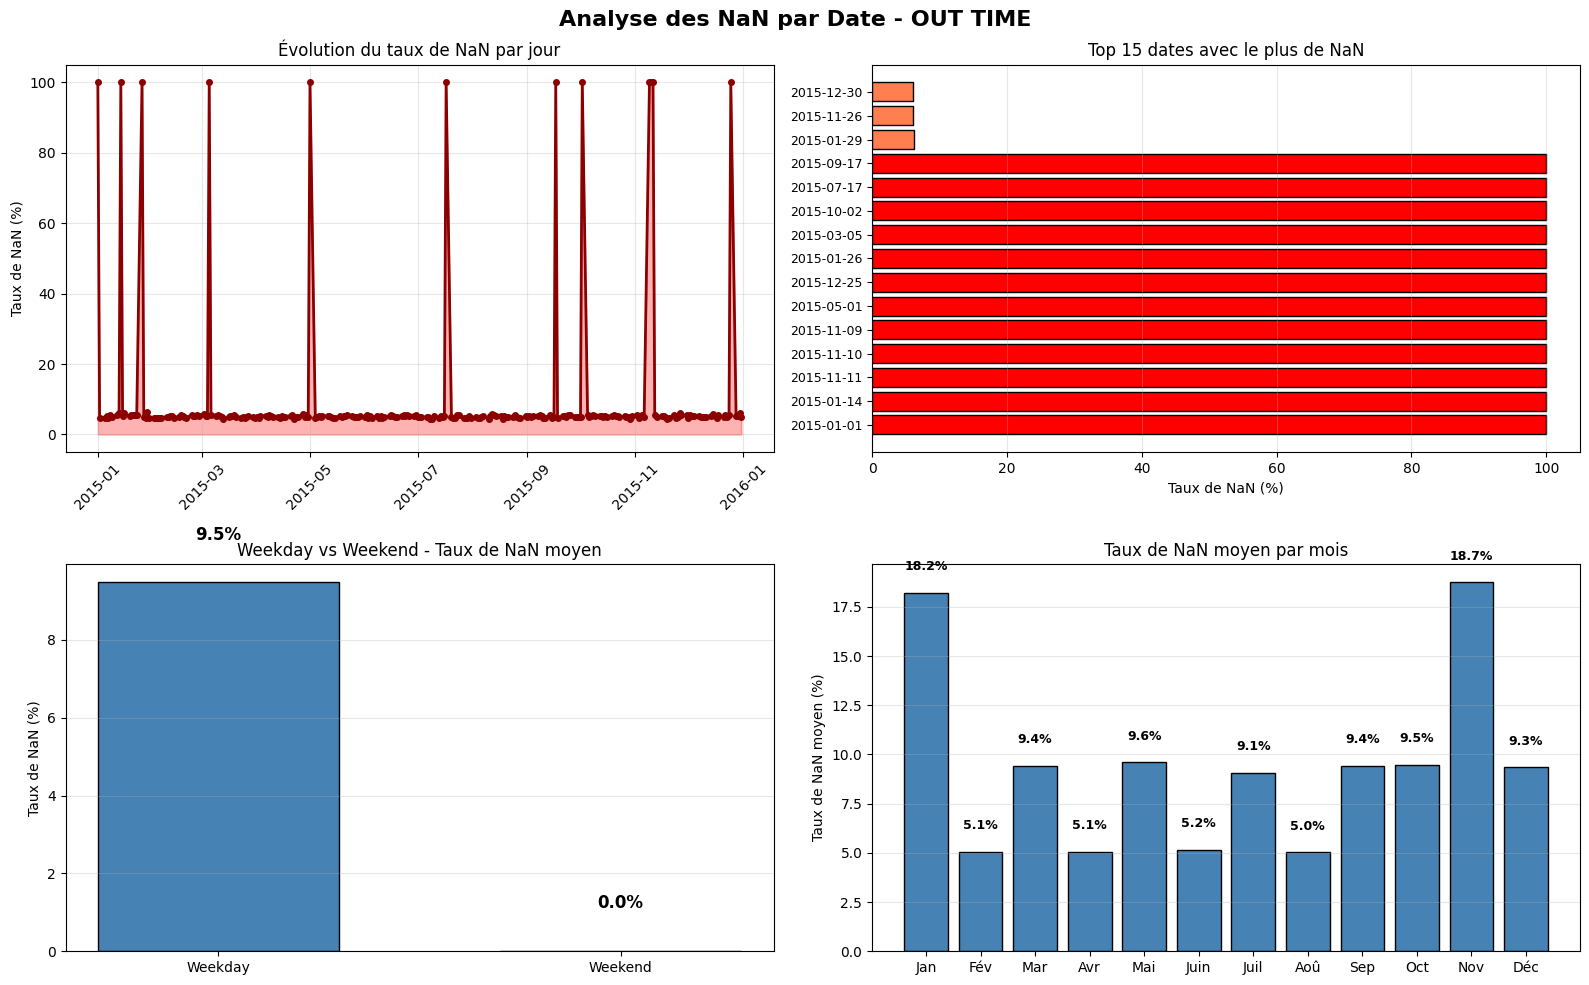


✓ Analyse OUT TIME complétée!


In [14]:
print("\n" + "=" * 80)
print("ANALYSE DES DATES DANS LES NOMS DE COLONNES - OUT TIME")
print("=" * 80)

# 1. EXTRAIRE LES DATES DES NOMS DE COLONNES
print("\n1. EXTRACTION DES DATES:")
print(f"   Dimensions: {data_out_time.shape}")
print(f"   Colonnes (premières): {list(data_out_time.columns[:5])}")

date_columns = data_out_time.columns[1:]
dates = [pd.to_datetime(col, errors='coerce') for col in date_columns]

daily_stats = []
for col, date in zip(date_columns, dates):
    if pd.notna(date):
        nan_count = data_out_time[col].isnull().sum()
        total_values = len(data_out_time)
        nan_rate = (nan_count / total_values * 100) if total_values > 0 else 0
        day_name = date.day_name()
        is_weekend = date.dayofweek >= 5
        month = date.month
        daily_stats.append({
            'Date': date,
            'DayName': day_name,
            'IsWeekend': is_weekend,
            'Month': month,
            'NaN_Count': nan_count,
            'Total_Values': total_values,
            'NaN_Rate_%': nan_rate
        })

daily_df = pd.DataFrame(daily_stats).sort_values('NaN_Rate_%', ascending=False)
print(f"   ✓ {len(daily_df)} dates détectées et analysées")

# TOP 20 DATES AVEC LE PLUS DE NaN
print("\n2. TOP 20 DATES AVEC LE PLUS DE NaN:")
print("-" * 80)
for idx, row in daily_df.head(20).iterrows():
    marker = "🔴" if row['IsWeekend'] else "⚪"
    print(f"   {marker} {row['Date'].strftime('%Y-%m-%d')} ({row['DayName'][:3]}) | "
          f"NaN: {int(row['NaN_Count'])}/{int(row['Total_Values'])} | "
          f"Rate: {row['NaN_Rate_%']:.2f}%")

# JOURS AVEC 100% DE NaN
print("\n3. JOURS AVEC 100% DE NaN:")
full_nan_dates = daily_df[daily_df['NaN_Rate_%'] >= 99.5]
print(f"   Nombre: {len(full_nan_dates)}")
if len(full_nan_dates) > 0:
    for idx, row in full_nan_dates.iterrows():
        marker = "🔴 WEEKEND" if row['IsWeekend'] else "🔴 WEEKDAY"
        print(f"   {marker} | {row['Date'].strftime('%Y-%m-%d')} ({row['DayName']})")

# STATISTIQUES GLOBALES
print("\n4. STATISTIQUES GLOBALES:")
weekday_df = daily_df[daily_df['IsWeekend'] == False]
weekend_df = daily_df[daily_df['IsWeekend'] == True]
weekday_avg = weekday_df['NaN_Rate_%'].mean() if len(weekday_df) > 0 else 0
weekend_avg = weekend_df['NaN_Rate_%'].mean() if len(weekend_df) > 0 else 0

print(f"\n   WEEKDAY (Lun-Ven):")
print(f"      • Nombre de jours: {len(weekday_df)}")
print(f"      • Taux NaN moyen: {weekday_avg:.2f}%")
if len(weekday_df)>0:
    print(f"      • Taux NaN min-max: {weekday_df['NaN_Rate_%'].min():.2f}% - {weekday_df['NaN_Rate_%'].max():.2f}%")

print(f"\n   WEEKEND (Sam-Dim):")
print(f"      • Nombre de jours: {len(weekend_df)}")
print(f"      • Taux NaN moyen: {weekend_avg:.2f}%")
if len(weekend_df)>0:
    print(f"      • Taux NaN min-max: {weekend_df['NaN_Rate_%'].min():.2f}% - {weekend_df['NaN_Rate_%'].max():.2f}%")

# ANALYSE PAR MOIS
print("\n5. ANALYSE PAR MOIS:")
monthly_stats = daily_df.groupby('Month').agg({
    'NaN_Rate_%': 'mean',
    'Date': 'count'
}).rename(columns={'Date': 'Nb_Days'})

months = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
          'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

for month_num, row in monthly_stats.iterrows():
    month_name = months[int(month_num)-1]
    print(f"   {month_name}: {int(row['Nb_Days'])} jours, {row['NaN_Rate_%']:.2f}% NaN moyen")

# VISUALISATIONS (identiques à l'analyse in_time)
print("\n6. CRÉATION DES VISUALISATIONS:")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des NaN par Date - OUT TIME', fontsize=16, fontweight='bold')

# Évolution temporelle
ax = axes[0, 0]
daily_df_sorted = daily_df.sort_values('Date')
ax.plot(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'],
        marker='o', linestyle='-', color='darkred', linewidth=2, markersize=4)
ax.fill_between(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'], alpha=0.3, color='red')
ax.set_title('Évolution du taux de NaN par jour')
ax.set_ylabel('Taux de NaN (%)')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Top 15
ax = axes[0, 1]
top_15 = daily_df.head(15)
colors_bar = ['red' if x >= 99 else 'orange' if x >= 80 else 'coral' for x in top_15['NaN_Rate_%']]
bars = ax.barh(range(len(top_15)), top_15['NaN_Rate_%'], color=colors_bar, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in top_15['Date']], fontsize=9)
ax.set_xlabel('Taux de NaN (%)')
ax.set_title('Top 15 dates avec le plus de NaN')
ax.grid(alpha=0.3, axis='x')

# Weekday vs Weekend
ax = axes[1, 0]
categories = ['Weekday', 'Weekend']
rates = [weekday_avg, weekend_avg]
colors = ['steelblue', 'orange']
bars = ax.bar(categories, rates, color=colors, edgecolor='black', width=0.6)
ax.set_ylabel('Taux de NaN (%)')
ax.set_title('Weekday vs Weekend - Taux de NaN moyen')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Par mois
ax = axes[1, 1]
month_names_short = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
month_labels_plot = [month_names_short[m-1] for m in monthly_stats.index]
bars = ax.bar(month_labels_plot, monthly_stats['NaN_Rate_%'], color='steelblue', edgecolor='black')
ax.set_ylabel('Taux de NaN moyen (%)')
ax.set_title('Taux de NaN moyen par mois')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, monthly_stats['NaN_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analyse OUT TIME complétée!")

## Nous avons fait le choix de supprimer les colonnes avec 100% de NaN et remplacer les lignes manquantes par la median horraires. Par la suite nous allons faire des statistiques sur les horraires de chaque employées

In [15]:
def get_daily_stats(df):
    date_cols = df.columns[1:]
    dates = [pd.to_datetime(c, errors='coerce') for c in date_cols]
    stats = []
    total = len(df)
    for col, date in zip(date_cols, dates):
        if pd.notna(date):
            nan_count = df[col].isnull().sum()
            nan_rate = nan_count / total * 100 if total>0 else 0
            stats.append({'Date': date.normalize(), 'NaN_Count': nan_count, 'Total': total, 'NaN_Rate_%': nan_rate})
    return pd.DataFrame(stats).drop_duplicates('Date').set_index('Date').sort_index()

in_stats = get_daily_stats(data_in_time)
out_stats = get_daily_stats(data_out_time)

# Sets by threshold
in_any = set(in_stats.index[in_stats['NaN_Count']>0])
out_any = set(out_stats.index[out_stats['NaN_Count']>0])

in_high = set(in_stats.index[in_stats['NaN_Rate_%']>=50])
out_high = set(out_stats.index[out_stats['NaN_Rate_%']>=50])

in_full = set(in_stats.index[in_stats['NaN_Rate_%']>=99.5])
out_full = set(out_stats.index[out_stats['NaN_Rate_%']>=99.5])

def summarize(a, b, name):
    inter = a & b
    only_a = a - b
    only_b = b - a
    total_union = len(a | b)
    overlap_pct = (len(inter) / total_union * 100) if total_union>0 else 0
    print(f"\n=== {name} ===")
    print(f"  In: {len(a)}  Out: {len(b)}  Intersection: {len(inter)}  Overlap: {overlap_pct:.1f}%")
    if len(inter)>0:
        print("  Exemples (communs):", ", ".join(sorted([d.strftime('%Y-%m-%d') for d in list(inter)[:10]])))
    if len(only_a)>0:
        print("  Exemples (uniques In):", ", ".join(sorted([d.strftime('%Y-%m-%d') for d in list(only_a)[:6]])))
    if len(only_b)>0:
        print("  Exemples (uniques Out):", ", ".join(sorted([d.strftime('%Y-%m-%d') for d in list(only_b)[:6]])))

summarize(in_any, out_any, "Jours avec AU MOINS 1 NaN")
summarize(in_high, out_high, "Jours avec >=50% NaN")
summarize(in_full, out_full, "Jours avec ~100% NaN (>=99.5%)")

# Optionnel: DataFrame récapitulatif pour inspection
combined = pd.DataFrame(index=sorted(set(in_stats.index) | set(out_stats.index)))
combined['in_NaN_%'] = in_stats['NaN_Rate_%']
combined['out_NaN_%'] = out_stats['NaN_Rate_%']
combined = combined.fillna(0)
combined['both_high?'] = (combined['in_NaN_%']>=50) & (combined['out_NaN_%']>=50)
combined.head(20)


=== Jours avec AU MOINS 1 NaN ===
  In: 261  Out: 261  Intersection: 261  Overlap: 100.0%
  Exemples (communs): 2015-02-25, 2015-05-08, 2015-07-22, 2015-08-31, 2015-09-28, 2015-10-20, 2015-11-11, 2015-12-10, 2015-12-17, 2015-12-22

=== Jours avec >=50% NaN ===
  In: 12  Out: 12  Intersection: 12  Overlap: 100.0%
  Exemples (communs): 2015-01-01, 2015-01-14, 2015-01-26, 2015-05-01, 2015-07-17, 2015-09-17, 2015-11-09, 2015-11-10, 2015-11-11, 2015-12-25

=== Jours avec ~100% NaN (>=99.5%) ===
  In: 12  Out: 12  Intersection: 12  Overlap: 100.0%
  Exemples (communs): 2015-01-01, 2015-01-14, 2015-01-26, 2015-05-01, 2015-07-17, 2015-09-17, 2015-11-09, 2015-11-10, 2015-11-11, 2015-12-25


,in_NaN_%,out_NaN_%,both_high?
2015-01-01,100.000000,100.000000,True
2015-01-02,4.739229,4.739229,False
2015-01-05,4.671202,4.671202,False
2015-01-06,5.170068,5.170068,False
2015-01-07,4.739229,4.739229,False
2015-01-08,5.510204,5.510204,False
2015-01-09,4.875283,4.875283,False
2015-01-12,5.419501,5.419501,False
2015-01-13,6.009070,6.009070,False
2015-01-14,100.000000,100.000000,True


In [16]:
import re
import pandas as pd
threshold = 0.90
def drop_sparse_cols(df, thresh=threshold, drop_all_nan=True):
    before = df.shape[1]
    if drop_all_nan:
        df = df.dropna(axis=1, how='all')  # supprime colonnes 100% NaN
    nan_rate = df.isnull().mean()
    to_drop = nan_rate[nan_rate >= thresh].index.tolist()
    to_drop = [c for c in to_drop if c != 'EmployeeID']
    df = df.drop(columns=to_drop)
    after = df.shape[1]
    print(f"Dropped {before-after} columns (kept {after}).")
    if to_drop:
        print("Examples dropped:", to_drop[:20])
    return df

data_in_time = drop_sparse_cols(data_in_time, thresh=threshold)
data_out_time = drop_sparse_cols(data_out_time, thresh=threshold)
# Wide -> long
in_long = data_in_time.melt(id_vars='EmployeeID', var_name='Date', value_name='InTime')
out_long = data_out_time.melt(id_vars='EmployeeID', var_name='Date', value_name='OutTime')
in_long['Date'] = pd.to_datetime(in_long['Date'], errors='coerce')
out_long['Date'] = pd.to_datetime(out_long['Date'], errors='coerce')

# Vectorized parsing: try full datetime parse first
in_dt = pd.to_datetime(in_long['InTime'], errors='coerce', infer_datetime_format=True)
out_dt = pd.to_datetime(out_long['OutTime'], errors='coerce', infer_datetime_format=True)

# For remaining NaT, combine Date + time (vectorized)
mask_in = in_dt.isna() & in_long['InTime'].notna()
if mask_in.any():
    in_dt.loc[mask_in] = pd.to_datetime(
        in_long.loc[mask_in, 'Date'].dt.strftime('%Y-%m-%d') + ' ' + in_long.loc[mask_in, 'InTime'],
        errors='coerce', infer_datetime_format=True)

mask_out = out_dt.isna() & out_long['OutTime'].notna()
if mask_out.any():
    out_dt.loc[mask_out] = pd.to_datetime(
        out_long.loc[mask_out, 'Date'].dt.strftime('%Y-%m-%d') + ' ' + out_long.loc[mask_out, 'OutTime'],
        errors='coerce', infer_datetime_format=True)

in_long['In_dt'] = in_dt
out_long['Out_dt'] = out_dt

# Merge
df = pd.merge(
    in_long[['EmployeeID','Date','InTime','In_dt']],
    out_long[['EmployeeID','Date','OutTime','Out_dt']],
    on=['EmployeeID','Date'],
    how='outer'
)

# Cross-midnight: add 1 day when Out < In
mask = df['In_dt'].notna() & df['Out_dt'].notna() & (df['Out_dt'] < df['In_dt'])
df.loc[mask, 'Out_dt'] = df.loc[mask, 'Out_dt'] + pd.Timedelta(days=1)

# Duration in hours
df['Duration'] = df['Out_dt'] - df['In_dt']
df['Hours'] = df['Duration'].dt.total_seconds() / 3600.0
df['OvertimeHours'] = (df['Hours'] - 8).clip(lower=0)
# Quick checks
print("Rows:", len(df))
print(df[['EmployeeID','Date','InTime','OutTime','In_dt','Out_dt','Hours']].head())
print(df['Hours'].describe())
print(df['OvertimeHours'].describe())



Dropped 12 columns (kept 250).
Dropped 12 columns (kept 250).


C:\Users\Natha\AppData\Local\Temp\ipykernel_47836\3177708054.py:27: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  in_dt = pd.to_datetime(in_long['InTime'], errors='coerce', infer_datetime_format=True)
C:\Users\Natha\AppData\Local\Temp\ipykernel_47836\3177708054.py:28: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  out_dt = pd.to_datetime(out_long['OutTime'], errors='coerce', infer_datetime_format=True)


Rows: 1098090
   EmployeeID       Date               InTime              OutTime  \
0           1 2015-01-02  2015-01-02 09:43:45  2015-01-02 16:56:15   
1           1 2015-01-05  2015-01-05 10:08:48  2015-01-05 17:20:11   
2           1 2015-01-06  2015-01-06 09:54:26  2015-01-06 17:19:05   
3           1 2015-01-07  2015-01-07 09:34:31  2015-01-07 16:34:55   
4           1 2015-01-08  2015-01-08 09:51:09  2015-01-08 17:08:32   

                In_dt              Out_dt     Hours  
0 2015-01-02 09:43:45 2015-01-02 16:56:15  7.208333  
1 2015-01-05 10:08:48 2015-01-05 17:20:11  7.189722  
2 2015-01-06 09:54:26 2015-01-06 17:19:05  7.410833  
3 2015-01-07 09:34:31 2015-01-07 16:34:55  7.006667  
4 2015-01-08 09:51:09 2015-01-08 17:08:32  7.289722  
count    1.041930e+06
mean     7.708607e+00
std      1.376132e+00
min      4.726944e+00
25%      6.662222e+00
50%      7.420278e+00
75%      8.397500e+00
max      1.208861e+01
Name: Hours, dtype: float64
count    1.041930e+06
mean     4.4410

In [17]:
# 1) Inspect# 1) Stats par employé (sans merge)
emp_stats = df.groupby('EmployeeID').agg(
    AvgWorkingHours=('Hours', 'mean'),
    StdWorkingHours=('Hours', 'std'),
    TotalHours=('Hours', 'sum'),
    DaysWorked=('Hours', 'count'),
    OvertimeDays=('Hours', lambda x: (x > 8).sum()),
    TotalOvertimeHours=('OvertimeHours', 'sum')   # <-- ajouté
).reset_index()


emp_stats['AvgOvertimePerDay'] = emp_stats['TotalOvertimeHours'] / emp_stats['DaysWorked']
print(emp_stats.head())





   EmployeeID  AvgWorkingHours  StdWorkingHours   TotalHours  DaysWorked  \
0           1         7.373651         0.283224  1710.686944         232   
1           2         7.718969         0.313351  1821.676667         236   
2           3         7.013240         0.311551  1697.204167         242   
3           4         7.193678         0.284133  1690.514444         235   
4           5         8.006175         0.300656  1961.512778         245   

   OvertimeDays  TotalOvertimeHours  AvgOvertimePerDay  
0             0            0.000000           0.000000  
1            42            6.522778           0.027639  
2             0            0.000000           0.000000  
3             0            0.000000           0.000000  
4           115           31.053333           0.126748  


Affichage de la distribution des colonnes

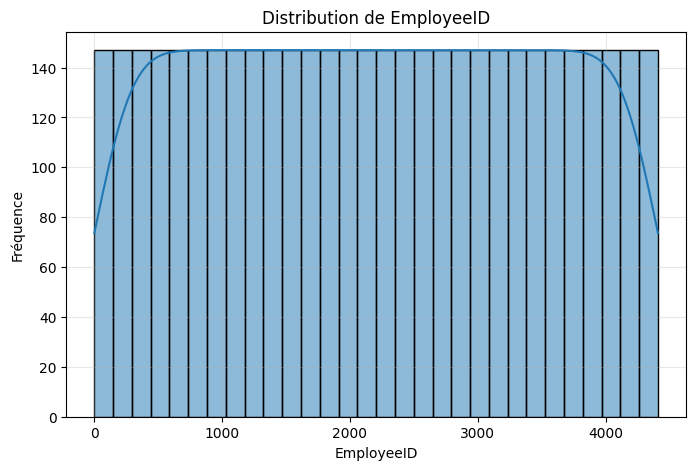

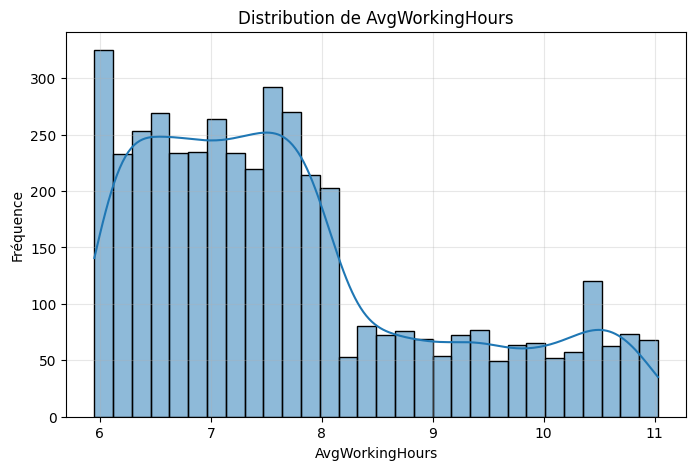

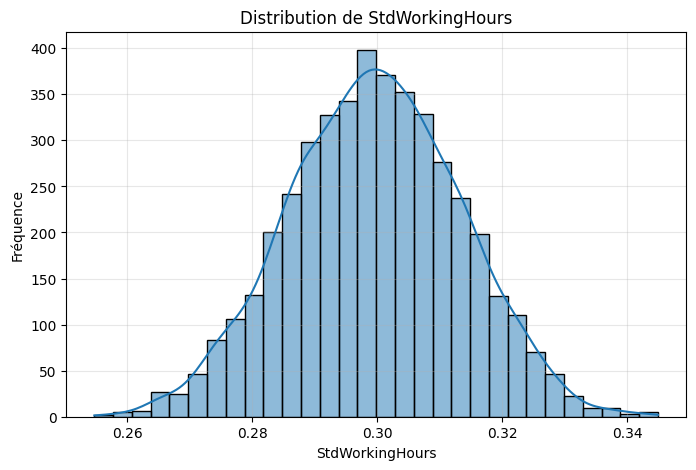

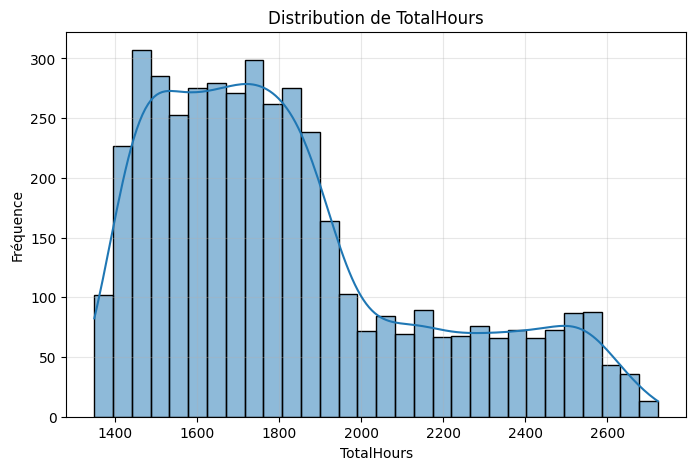

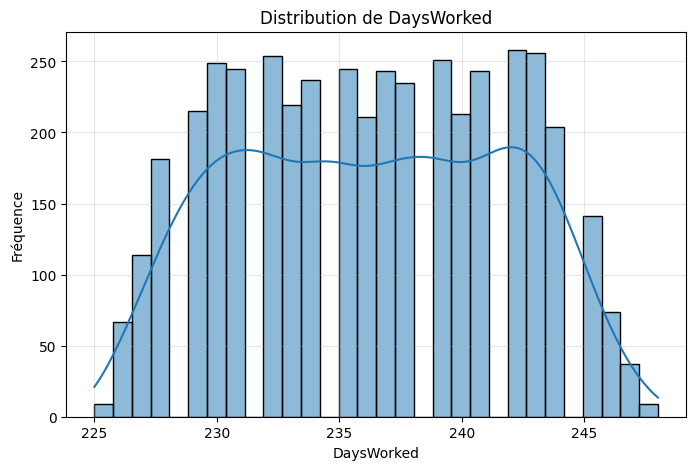

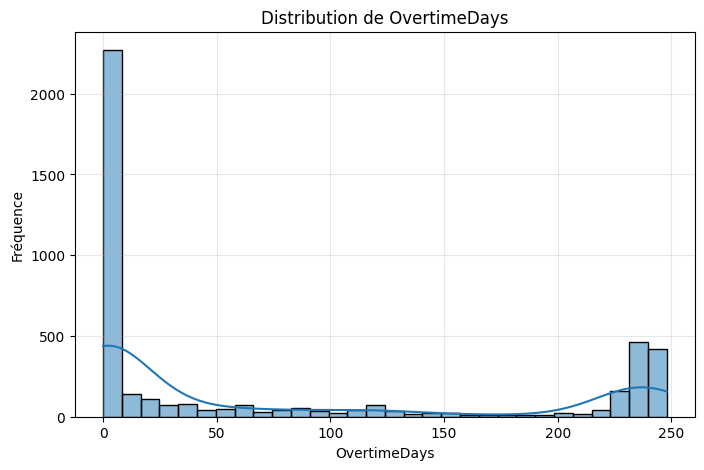

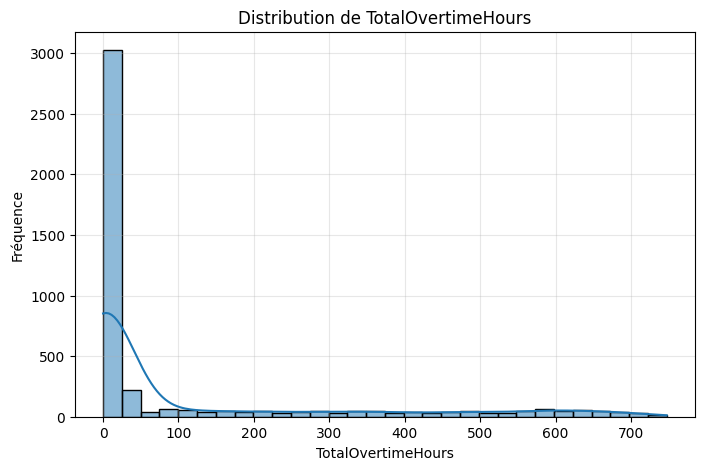

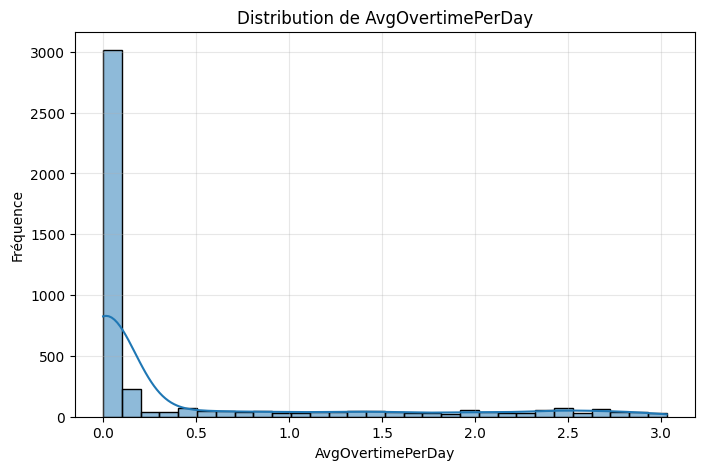

In [19]:
# Tracer histogramme de chaque colonne
for col in emp_stats.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(emp_stats[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.grid(alpha=0.3)
    plt.show()

## Enregistrement de notre csv de stats horraires

In [18]:
emp_stats.to_csv('../Output/employee_hours_stats.csv', index=False)
print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['EmployeeID', 'Date', 'InTime', 'In_dt', 'OutTime', 'Out_dt', 'Duration', 'Hours', 'OvertimeHours']
   EmployeeID       Date               InTime               In_dt  \
0           1 2015-01-02  2015-01-02 09:43:45 2015-01-02 09:43:45   
1           1 2015-01-05  2015-01-05 10:08:48 2015-01-05 10:08:48   
2           1 2015-01-06  2015-01-06 09:54:26 2015-01-06 09:54:26   
3           1 2015-01-07  2015-01-07 09:34:31 2015-01-07 09:34:31   
4           1 2015-01-08  2015-01-08 09:51:09 2015-01-08 09:51:09   

               OutTime              Out_dt        Duration     Hours  \
0  2015-01-02 16:56:15 2015-01-02 16:56:15 0 days 07:12:30  7.208333   
1  2015-01-05 17:20:11 2015-01-05 17:20:11 0 days 07:11:23  7.189722   
2  2015-01-06 17:19:05 2015-01-06 17:19:05 0 days 07:24:39  7.410833   
3  2015-01-07 16:34:55 2015-01-07 16:34:55 0 days 07:00:24  7.006667   
4  2015-01-08 17:08:32 2015-01-08 17:08:32 0 days 07:17:23  7.289722   

   OvertimeHours  
0            0.0  
1   

## Et enfin, merge du fichier stats horraires avec notre premiere dataframe.

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df1 = pd.read_csv('../Output/general_data_merged.csv')
df2 = pd.read_csv('../Output/employee_hours_stats.csv')
df_merged = pd.merge(df1, df2, on="EmployeeID", how="left")
df_merged.describe()


,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,...,WorkLifeBalance,JobInvolvement,PerformanceRating,AvgWorkingHours,StdWorkingHours,TotalHours,DaysWorked,OvertimeDays,TotalOvertimeHours,AvgOvertimePerDay
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.0,...,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.691837,15.209524,8.0,...,2.763492,2.729932,3.153741,7.700792,0.299578,1821.276283,236.265306,76.153061,104.925669,0.439821
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.493912,3.659108,0.0,...,0.703541,0.711400,0.360742,1.340218,0.013721,331.361528,5.503779,100.020061,197.628527,0.826982
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,...,1.000000,1.000000,3.000000,5.950504,0.254754,1348.803056,225.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,...,2.000000,2.000000,3.000000,6.673333,0.289964,1563.572500,232.000000,0.000000,0.000000,0.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,...,3.000000,3.000000,3.000000,7.406761,0.299544,1745.782222,236.000000,6.000000,0.668056,0.002834
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,...,3.000000,3.000000,3.000000,8.368703,0.308990,1967.295347,241.000000,205.000000,90.430000,0.383911
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,...,4.000000,4.000000,4.000000,11.030960,0.344907,2723.378056,248.000000,248.000000,747.378056,3.030960


In [22]:
df_merged.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,WorkLifeBalance,JobInvolvement,PerformanceRating,AvgWorkingHours,StdWorkingHours,TotalHours,DaysWorked,OvertimeDays,TotalOvertimeHours,AvgOvertimePerDay
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,2.0,3,3,7.373651,0.283224,1710.686944,232,0,0.000000,0.000000
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,4.0,2,4,7.718969,0.313351,1821.676667,236,42,6.522778,0.027639
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,3,3,7.013240,0.311551,1697.204167,242,0,0.000000,0.000000
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,2,3,7.193678,0.284133,1690.514444,235,0,0.000000,0.000000
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,3.0,3,3,8.006175,0.300656,1961.512778,245,115,31.053333,0.126748


In [21]:
df_merged.to_csv("../Output/final_df.csv")

# Réalisation de la pipeline, standarisation de notre df pour nos models de ML/IA

Sachant que nous avons gerer tout les Nan en amont, notre fichier final_df.csv ne devrait plus contenir de NaN. Nous allons quand meme verifier à l'aider de .info()

In [23]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay


final_df = pd.read_csv("../Output/final_df.csv", index_col=0)
print(final_df.info())
print(final_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 4410 entries, 0 to 4409
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4410

In [47]:
print(final_df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender',
       'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
       'JobInvolvement', 'PerformanceRating', 'AvgWorkingHours',
       'StdWorkingHours', 'TotalHours', 'DaysWorked', 'OvertimeDays',
       'TotalOvertimeHours', 'AvgOvertimePerDay'],
      dtype='object')


# Matrice de correlation

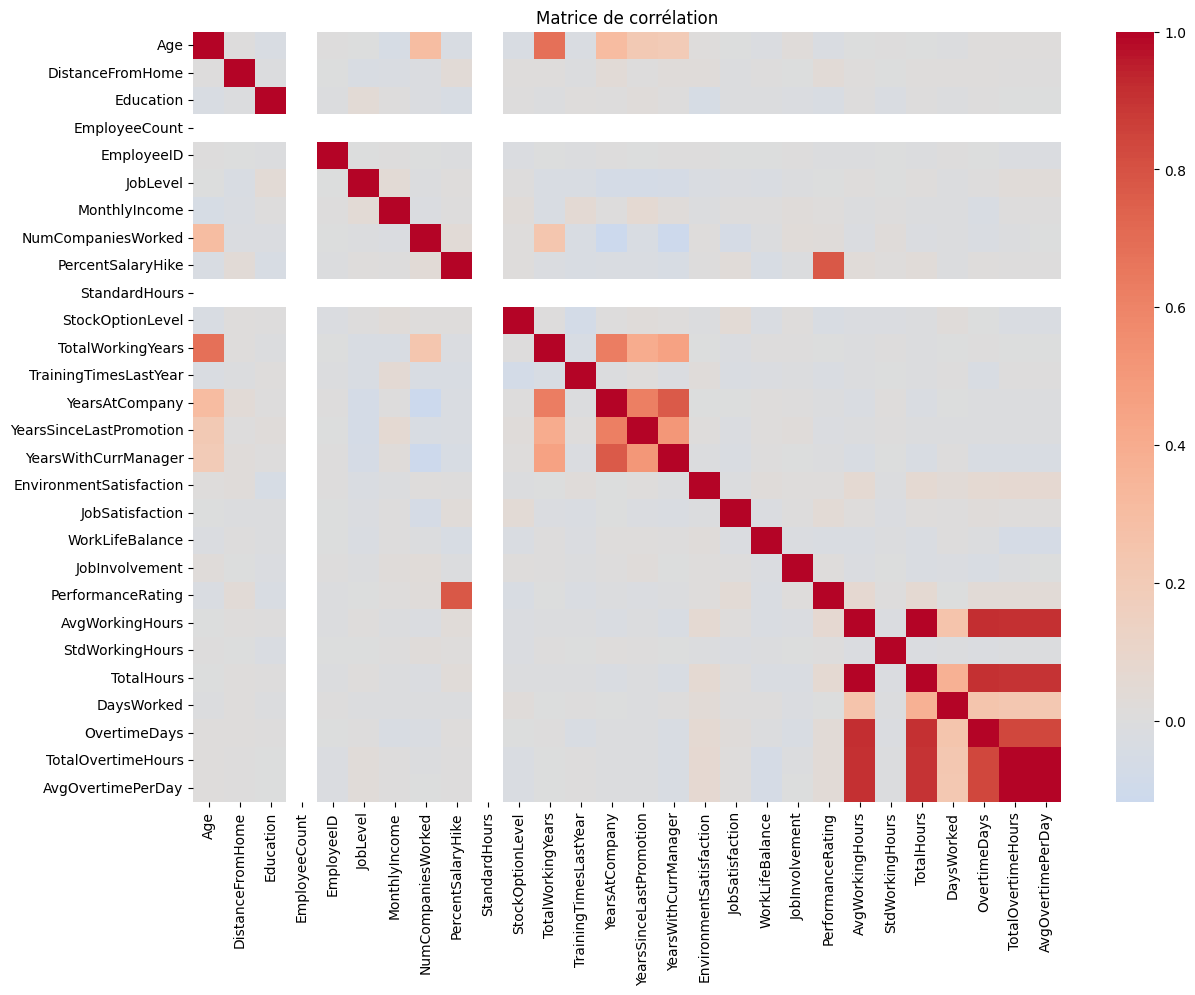

In [49]:
corr = final_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

In [53]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# colonnes avec corrélation > 0.8
threshold = 0.8
high_corr = (
    upper.stack()
    .reset_index()
)

high_corr.columns = ["Variable_1", "Variable_2", "Correlation"]
high_corr = high_corr[high_corr["Correlation"] > threshold]
high_corr = high_corr.sort_values(by="Correlation", ascending=False)

print(high_corr)

             Variable_1          Variable_2  Correlation
324  TotalOvertimeHours   AvgOvertimePerDay     0.999686
305     AvgWorkingHours          TotalHours     0.992124
307     AvgWorkingHours        OvertimeDays     0.914363
316          TotalHours        OvertimeDays     0.910063
309     AvgWorkingHours   AvgOvertimePerDay     0.908147
308     AvgWorkingHours  TotalOvertimeHours     0.907473
317          TotalHours  TotalOvertimeHours     0.903764
318          TotalHours   AvgOvertimePerDay     0.902584
323        OvertimeDays   AvgOvertimePerDay     0.837403
322        OvertimeDays  TotalOvertimeHours     0.836795


## Gestion des colonnes constantes que ne sont pas utiles de garder  

In [50]:
# Colonnes constantes
constant_cols = [c for c in final_df.columns if final_df[c].nunique(dropna=False) == 1]
print("Colonnes constantes:", constant_cols)

# Suppression des colonnes constantes
df_clean1 = final_df.drop(columns=constant_cols).copy()
print("Shape apres nettoyage:", df_clean1.shape)



Colonnes constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Shape apres nettoyage: (4410, 33)


# Mise en place du filtre ethique :

In [55]:
columns_n_ethique = ["JobInvolvement",
"PerformanceRating",
"Gender",
"MaritalStatus"]
df_clean2 = df_clean1.drop(columns=columns_n_ethique).copy()

# Supprimer certaines colonnes trop corelé

In [57]:
columns_corr =  ["AvgWorkingHours"]
df_clean = df_clean2.drop(columns=columns_corr).copy()

In [58]:
df_clean.info

<bound method DataFrame.info of       Age Attrition     BusinessTravel              Department  \
0      51        No      Travel_Rarely                   Sales   
1      31       Yes  Travel_Frequently  Research & Development   
2      32        No  Travel_Frequently  Research & Development   
3      38        No         Non-Travel  Research & Development   
4      32        No      Travel_Rarely  Research & Development   
...   ...       ...                ...                     ...   
4405   42        No      Travel_Rarely  Research & Development   
4406   29        No      Travel_Rarely  Research & Development   
4407   25        No      Travel_Rarely  Research & Development   
4408   42        No      Travel_Rarely                   Sales   
4409   40        No      Travel_Rarely  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeID  JobLevel  \
0                    6          2  Life Sciences           1         1   
1                   10     

## Séparation des données en part égale avec l'utilisation de StratifiedShuffleSplit.
Train - Test

In [59]:
# ============================================
# 1) Separation target / features
# ============================================
TARGET = "Attrition"

X = df_clean.drop(columns=[TARGET]).copy()
y = df_clean[TARGET].copy()

# Encodage binaire de la target (Yes/No -> 1/0)
y = y.map({"Yes": 1, "No": 0})

# ============================================
# 2) Split stratifie
# ============================================
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)



Train: (3528, 27) (3528,)
Test : (882, 27) (882,)


# 3) Pipeline de preprocessing

In [60]:

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Colonnes numeriques:", num_cols)
print("Colonnes categorielles:", cat_cols)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])



Colonnes numeriques: ['Age', 'DistanceFromHome', 'Education', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'StdWorkingHours', 'TotalHours', 'DaysWorked', 'OvertimeDays', 'TotalOvertimeHours', 'AvgOvertimePerDay']
Colonnes categorielles: ['BusinessTravel', 'Department', 'EducationField', 'JobRole']


# 4) Fit sur train puis transform train/test

In [61]:

X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)



X_train_prepared: (3528, 44)
X_test_prepared : (882, 44)


# 5) Logistic Regression + Graphiques


Accuracy : 0.856
Precision: 0.6154
Recall   : 0.2817
F1-score : 0.3865
ROC-AUC  : 0.8122

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       740
           1       0.62      0.28      0.39       142

    accuracy                           0.86       882
   macro avg       0.75      0.62      0.65       882
weighted avg       0.83      0.86      0.83       882



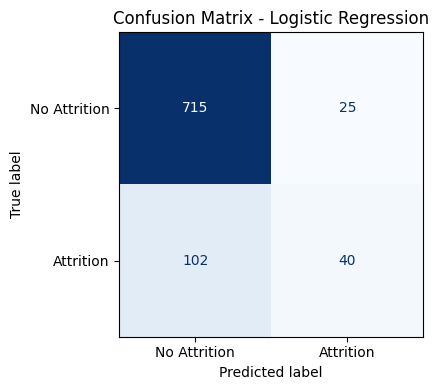

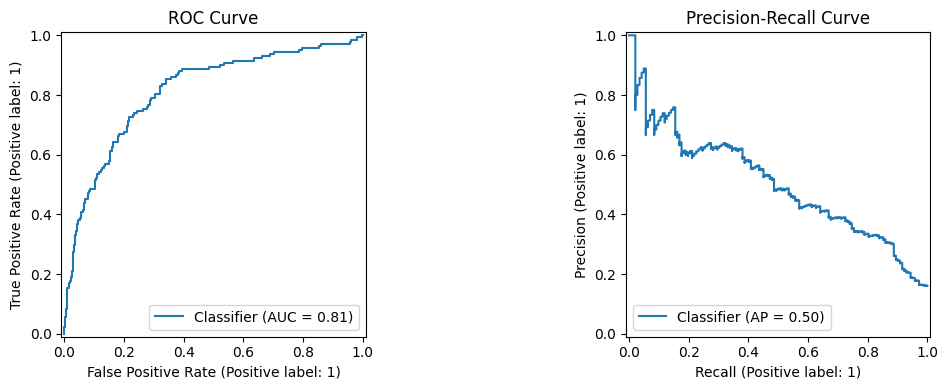

In [62]:

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared, y_train)

y_pred = log_reg.predict(X_test_prepared)
y_proba = log_reg.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



# Decision Tree

In [63]:
# Cellule 1: Entrainer un Decision Tree + importance des variables
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dt = DecisionTreeClassifier(
    max_depth=None,              # mets None si tu veux arbre complet (souvent illisible)
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train_prepared, y_train)

# Evaluation rapide
y_pred_dt = dt.predict(X_test_prepared)
y_proba_dt = dt.predict_proba(X_test_prepared)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1-score :", round(f1_score(y_test, y_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_dt), 4))

# Noms des features transformées (num + one-hot)
feature_names = full_pipeline.get_feature_names_out()

# Importance au niveau des features transformées
imp_df = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 features transformées:")
display(imp_df.head(20))


Accuracy : 0.8481
Precision: 0.5185
Recall   : 0.7887
F1-score : 0.6257
ROC-AUC  : 0.8826

Top 20 features transformées:


,feature_transformed,importance
9,num__TotalWorkingYears,0.142745
20,num__OvertimeDays,0.132051
0,num__Age,0.121242
15,num__JobSatisfaction,0.053849
7,num__PercentSalaryHike,0.053392
6,num__NumCompaniesWorked,0.049690
10,num__TrainingTimesLastYear,0.049146
12,num__YearsSinceLastPromotion,0.039361
14,num__EnvironmentSatisfaction,0.039076
5,num__MonthlyIncome,0.038219


Top 15 colonnes les plus impactantes sur l'attrition (Decision Tree):


,feature_original,importance
21,TotalWorkingYears,0.142745
15,OvertimeDays,0.132051
0,Age,0.121242
12,JobSatisfaction,0.053849
16,PercentSalaryHike,0.053392
14,NumCompaniesWorked,0.049690
22,TrainingTimesLastYear,0.049146
25,YearsSinceLastPromotion,0.039361
9,EnvironmentSatisfaction,0.039076
13,MonthlyIncome,0.038219


C:\Users\Natha\AppData\Local\Temp\ipykernel_47836\2293445261.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


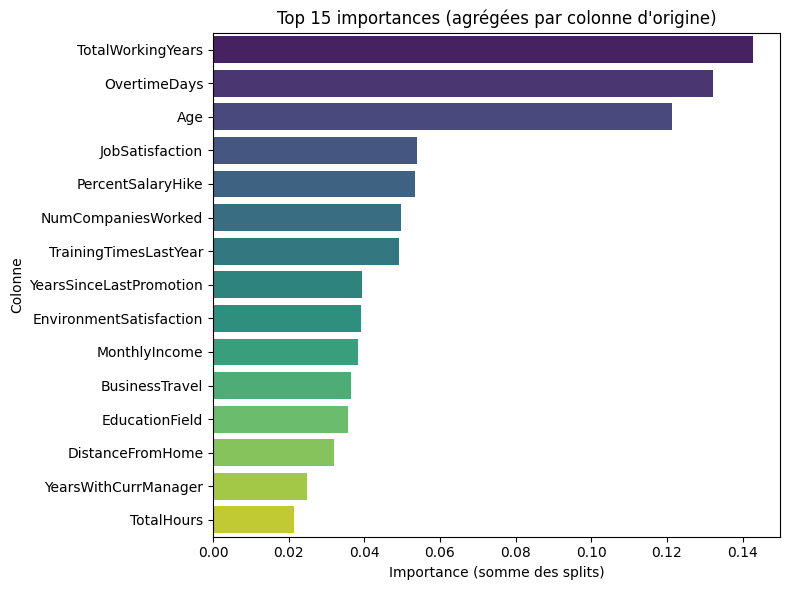

In [64]:
# Cellule 2: Regrouper les importances par colonne d'origine (très utile pour expliquer l'attrition)
def original_feature_name(transformed_name, num_cols, cat_cols):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "", 1)

    if transformed_name.startswith("cat__"):
        rest = transformed_name.replace("cat__", "", 1)
        # on prend la colonne catégorielle la plus longue qui match le début
        for c in sorted(cat_cols, key=len, reverse=True):
            if rest == c or rest.startswith(c + "_"):
                return c
        return rest

    return transformed_name

imp_df["feature_original"] = imp_df["feature_transformed"].apply(
    lambda x: original_feature_name(x, num_cols, cat_cols)
)

imp_grouped = (imp_df
               .groupby("feature_original", as_index=False)["importance"]
               .sum()
               .sort_values("importance", ascending=False))

print("Top 15 colonnes les plus impactantes sur l'attrition (Decision Tree):")
display(imp_grouped.head(15))

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=imp_grouped.head(15),
    x="importance",
    y="feature_original",
    palette="viridis"
)
plt.title("Top 15 importances (agrégées par colonne d'origine)")
plt.xlabel("Importance (somme des splits)")
plt.ylabel("Colonne")
plt.tight_layout()
plt.show()


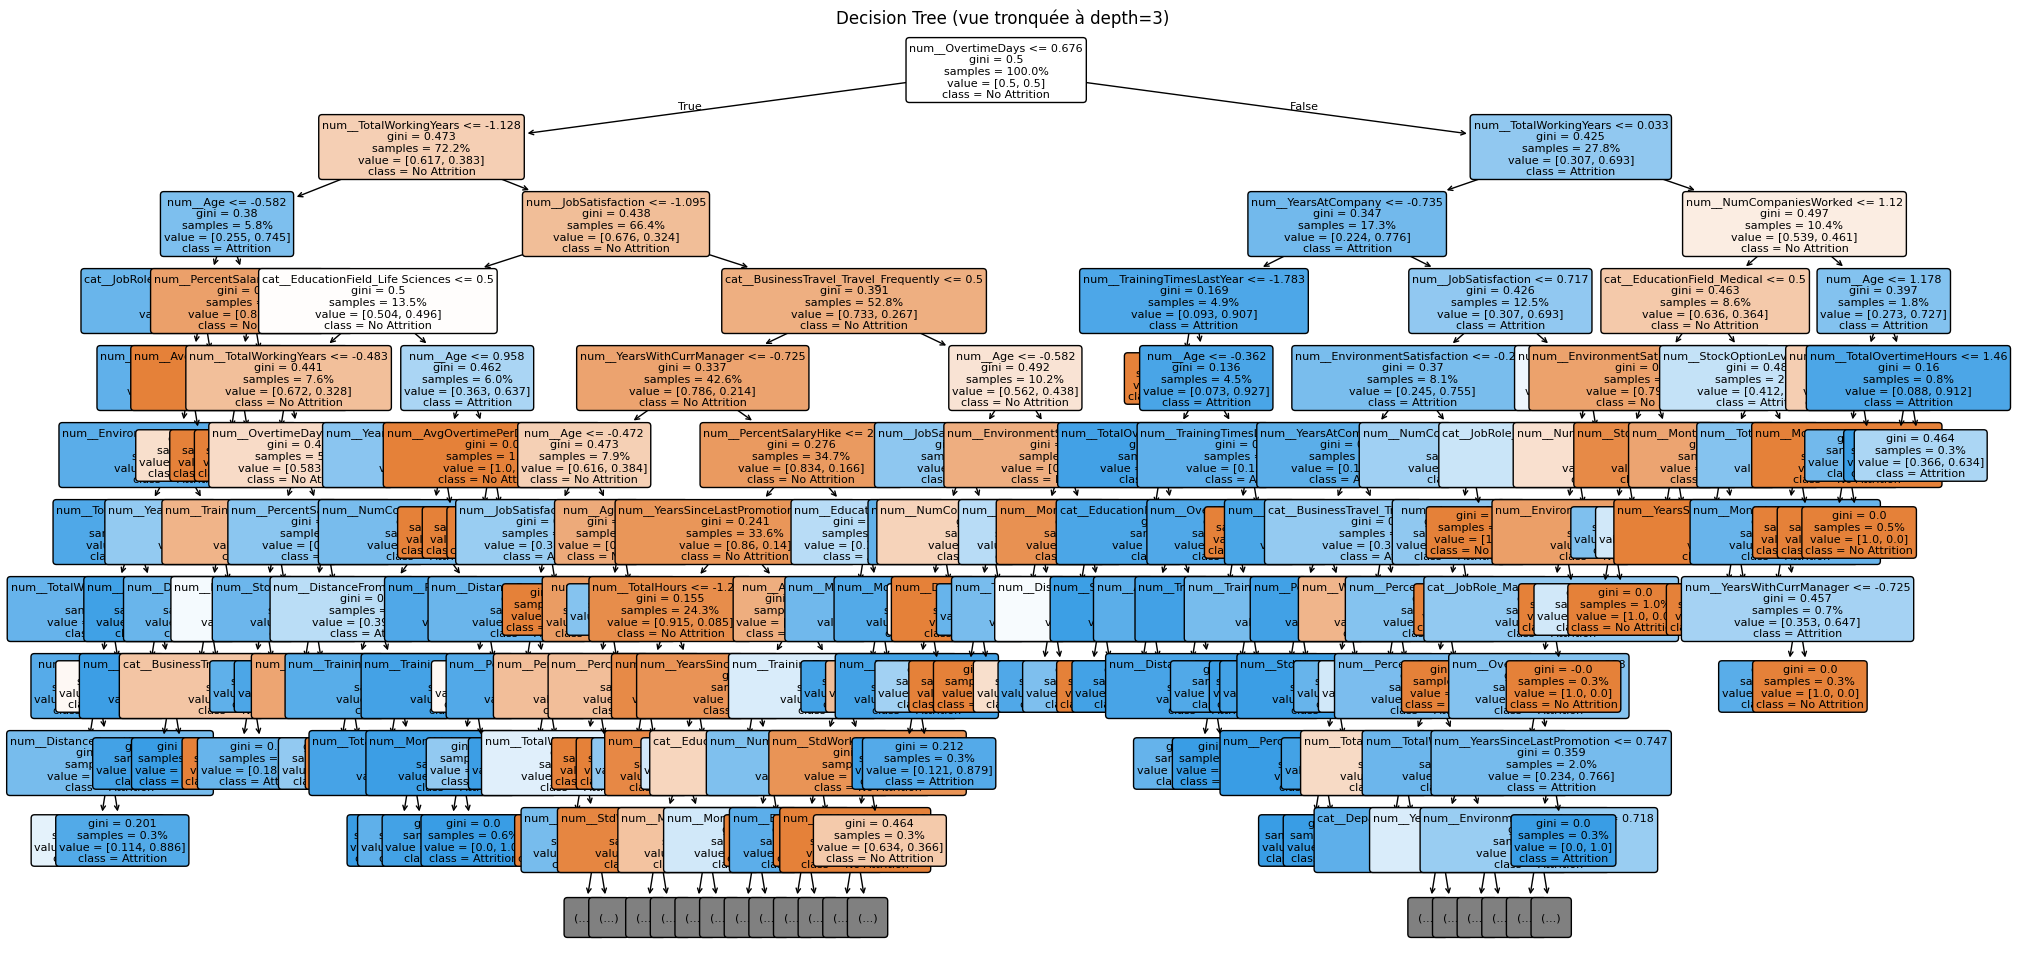

|--- num__OvertimeDays <= 0.676
|   |--- num__TotalWorkingYears <= -1.128
|   |   |--- num__Age <= -0.582
|   |   |   |--- cat__JobRole_Sales Representative <= 0.500
|   |   |   |   |--- num__MonthlyIncome <= 1.193
|   |   |   |   |   |--- num__EnvironmentSatisfaction <= 0.718
|   |   |   |   |   |   |--- num__TotalHours <= -0.528
|   |   |   |   |   |   |   |--- num__TotalWorkingYears <= -1.257
|   |   |   |   |   |   |   |   |--- num__Age <= -1.572
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- num__Age >  -1.572
|   |   |   |   |   |   |   |   |   |--- num__DistanceFromHome <= -0.710
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- num__DistanceFromHome >  -0.710
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- num__TotalWorkingYears >  -1.257
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- num__TotalHours >  -0.528
|   |   |   |   | 

In [65]:
# Cellule 3: Afficher l'arbre de décision + règles IF/ELSE
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(24, 12))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["No Attrition", "Attrition"],
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=10,     # pour lisibilité visuelle
    fontsize=8
)
plt.title("Decision Tree (vue tronquée à depth=3)")
plt.show()

# Règles IF/ELSE textuelles complètes
rules = export_text(dt, feature_names=list(feature_names), decimals=3)
print(rules)


# 6) Random Forest Classifier + Graphiques

Accuracy : 0.9717
Precision: 1.0
Recall   : 0.8239
F1-score : 0.9035
ROC-AUC  : 0.9943

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       740
           1       1.00      0.82      0.90       142

    accuracy                           0.97       882
   macro avg       0.98      0.91      0.94       882
weighted avg       0.97      0.97      0.97       882



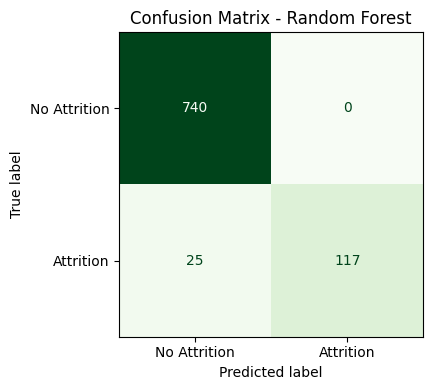

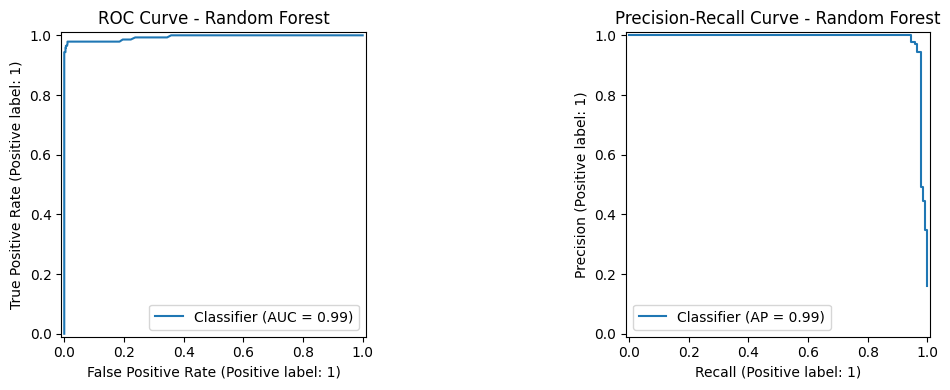

In [66]:

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared, y_train)

y_pred_rf = rf.predict(X_test_prepared)
y_proba_rf = rf.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


# 6) MLP + Graphiques

Accuracy : 0.983
Precision: 0.9847
Recall   : 0.9085
F1-score : 0.9451
ROC-AUC  : 0.9846

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       740
           1       0.98      0.91      0.95       142

    accuracy                           0.98       882
   macro avg       0.98      0.95      0.97       882
weighted avg       0.98      0.98      0.98       882


Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       740
           1       1.00      0.82      0.90       142

    accuracy                           0.97       882
   macro avg       0.98      0.91      0.94       882
weighted avg       0.97      0.97      0.97       882



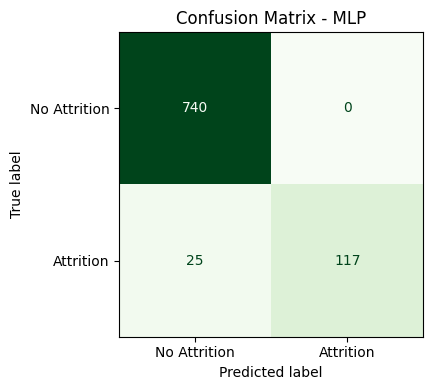

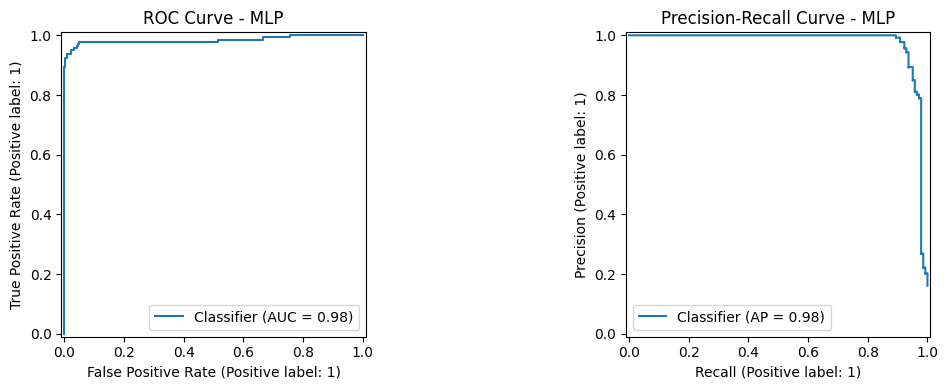

In [67]:
from sklearn.neural_network import MLPClassifier
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared, y_train)

y_pred_mlp = mlp.predict(X_test_prepared)
y_proba_mlp = mlp.predict_proba(X_test_prepared)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()



In [44]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Importance sur le set test (plus fiable pour l'interprétation)
perm = permutation_importance(
    estimator=mlp,
    X=X_test_prepared,
    y=y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",   # ou "f1", "accuracy"
    n_jobs=-1
)

# 2) Noms des features transformées (num + one-hot)
feature_names = full_pipeline.get_feature_names_out()

imp_mlp = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 20 features transformées (MLP):")
display(imp_mlp.head(20))


Top 20 features transformées (MLP):


,feature_transformed,importance_mean,importance_std
9,num__TotalWorkingYears,0.061520,0.008311
23,num__OvertimeDays,0.039149,0.005139
10,num__TrainingTimesLastYear,0.031103,0.004647
11,num__YearsAtCompany,0.029394,0.006862
12,num__YearsSinceLastPromotion,0.028457,0.002978
15,num__JobSatisfaction,0.025165,0.004103
16,num__WorkLifeBalance,0.024870,0.003181
14,num__EnvironmentSatisfaction,0.024002,0.003600
6,num__NumCompaniesWorked,0.022584,0.003708
18,num__PerformanceRating,0.018630,0.002104


Top 15 colonnes d'origine les plus importantes (MLP):


,feature_original,importance_mean
26,TotalWorkingYears,0.061520
19,OvertimeDays,0.039149
27,TrainingTimesLastYear,0.031103
29,YearsAtCompany,0.029394
30,YearsSinceLastPromotion,0.028457
15,JobSatisfaction,0.025165
28,WorkLifeBalance,0.024870
10,EnvironmentSatisfaction,0.024002
18,NumCompaniesWorked,0.022584
21,PerformanceRating,0.018630


C:\Users\Natha\AppData\Local\Temp\ipykernel_47836\86246425.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


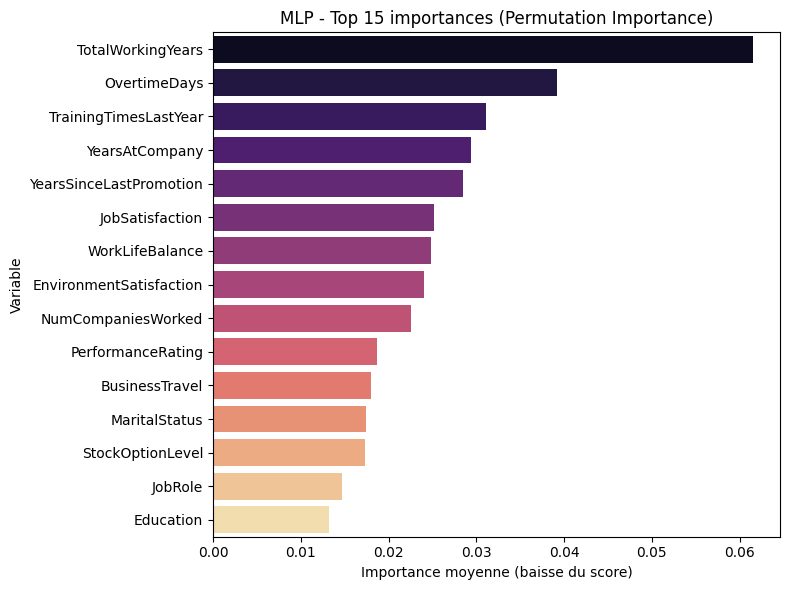

In [45]:
def original_feature_name(transformed_name, num_cols, cat_cols):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "", 1)

    if transformed_name.startswith("cat__"):
        rest = transformed_name.replace("cat__", "", 1)
        for c in sorted(cat_cols, key=len, reverse=True):
            if rest == c or rest.startswith(c + "_"):
                return c
        return rest

    return transformed_name

imp_mlp["feature_original"] = imp_mlp["feature_transformed"].apply(
    lambda x: original_feature_name(x, num_cols, cat_cols)
)

imp_mlp_grouped = (
    imp_mlp.groupby("feature_original", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)

print("Top 15 colonnes d'origine les plus importantes (MLP):")
display(imp_mlp_grouped.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(
    data=imp_mlp_grouped.head(15),
    x="importance_mean",
    y="feature_original",
    palette="magma"
)
plt.title("MLP - Top 15 importances (Permutation Importance)")
plt.xlabel("Importance moyenne (baisse du score)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()
